# 2D WTMM Analysis — Python Port of xsmurf

Complete implementation of the 2D Wavelet Transform Modulus Maxima (WTMM) method,
ported from the xsmurf C codebase. Includes:

1. **MLX GPU FFT-based 2D CWT** with Gaussian derivative wavelets (ψ_x, ψ_y)
2. **Mirror padding** to eliminate periodic FFT border artifacts (from `cv2d_n.c`)
3. **Gradient modulus & argument** (scalar field analysis)
4. **Tensor SVD** for vector field analysis (optional)
5. **Non-maxima suppression** with bilinear interpolation (from `edge/extrema_core.c`)
6. **Chain extraction** via connected component labeling (replaces `wt2d/chain.c`)
7. **Vertical chaining / skeleton** construction (from `wt2d/vertical_chain.c`)
8. **ChainDelete** — prune unchained/sign-changing extrema (from `ext_chain.c`)
9. **ChainMax** — scale-adaptive supremum along chains (from `ext_chain.c`)
10. **Arrow visualization** — gradient direction quiver plots (Arneodo et al. Fig. 5)
11. **3D skeleton view** — (x, y, log₂(a)) scale-space visualization (Arneodo et al. Fig. 6)
12. **Partition function** Z(q,a) with all 7 LastWave arrays and **D(h) singularity spectrum**

In [ ]:
import numpy as np
from numpy.fft import fftfreq  # MLX lacks fftfreq; keep numpy for grid construction
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx

print(f"NumPy {np.__version__}")
print(f"MLX  {mx.__version__}")
print("Backend: MLX GPU FFT + NumPy post-processing")

NumPy 2.4.2
MLX  0.31.0
Backend: MLX GPU FFT + NumPy post-processing


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5_path = '/Volumes/AbeMBeats/new_data_asif/velocity.h5'

with h5py.File(h5_path, 'r') as f:
    print("Keys:", list(f.keys()))
    
    vel = f['velocity'][:]
    print("velocity shape:", vel.shape)
    print("dtype:", vel.dtype)

Keys: ['intercept', 'interceptStd', 'residue', 'velocity', 'velocityStd']
velocity shape: (3029, 4855)
dtype: float32


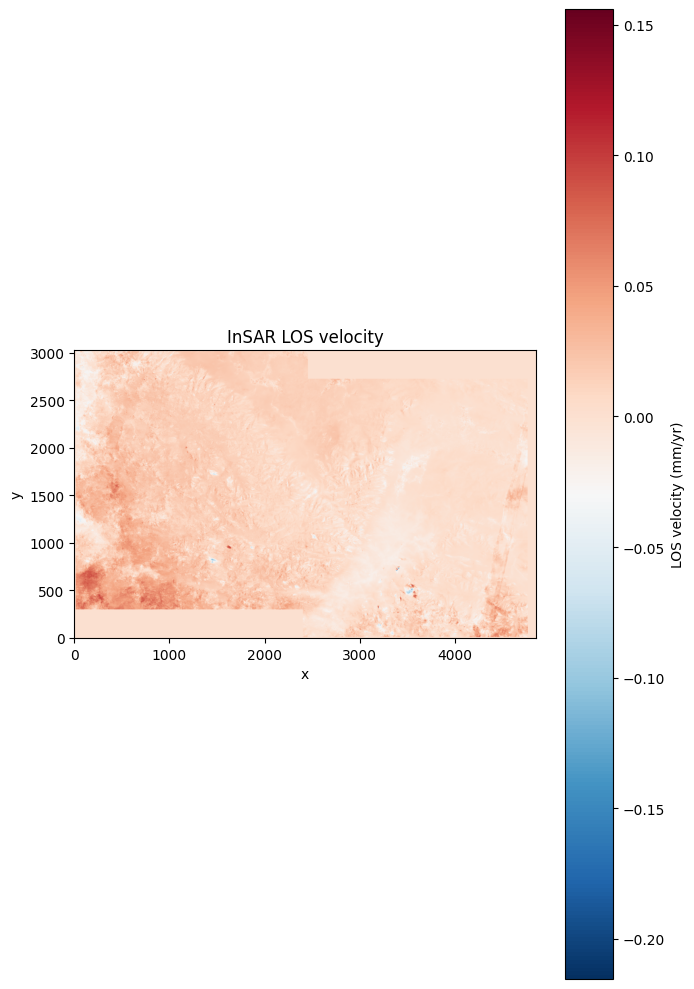

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5_path = '/Volumes/AbeMBeats/new_data_asif/velocity.h5'

with h5py.File(h5_path, 'r') as f:
    vel = f['velocity'][:]

# If velocity is 2D: (ny, nx)
if vel.ndim == 2:
    vel2d = vel

# If velocity is 3D but only one layer: (1, ny, nx)
elif vel.ndim == 3 and vel.shape[0] == 1:
    vel2d = vel[0]

else:
    raise ValueError(f"Unexpected velocity shape: {vel.shape}")

plt.figure(figsize=(7, 10))
im = plt.imshow(vel2d, origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='LOS velocity (mm/yr)')
plt.title('InSAR LOS velocity')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

In [ ]:
pip install h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.3 MB/s  0:00:02 eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/amasaryk/projects/Creep/wavelet/WTMM_ultimate/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Test Image — Generate Synthetic Fractal

We generate a 2D fractional Brownian field (fBm) with known Hurst exponent H,
so we can validate the D(h) spectrum. We also add some point singularities.

Test image shape: (256, 256)
Padded shape:     (320, 320) (pad=32)
Crop slice:       (slice(32, 288, None), slice(32, 288, None))
True Hurst exponent: H = 0.7
Added 5 point singularities


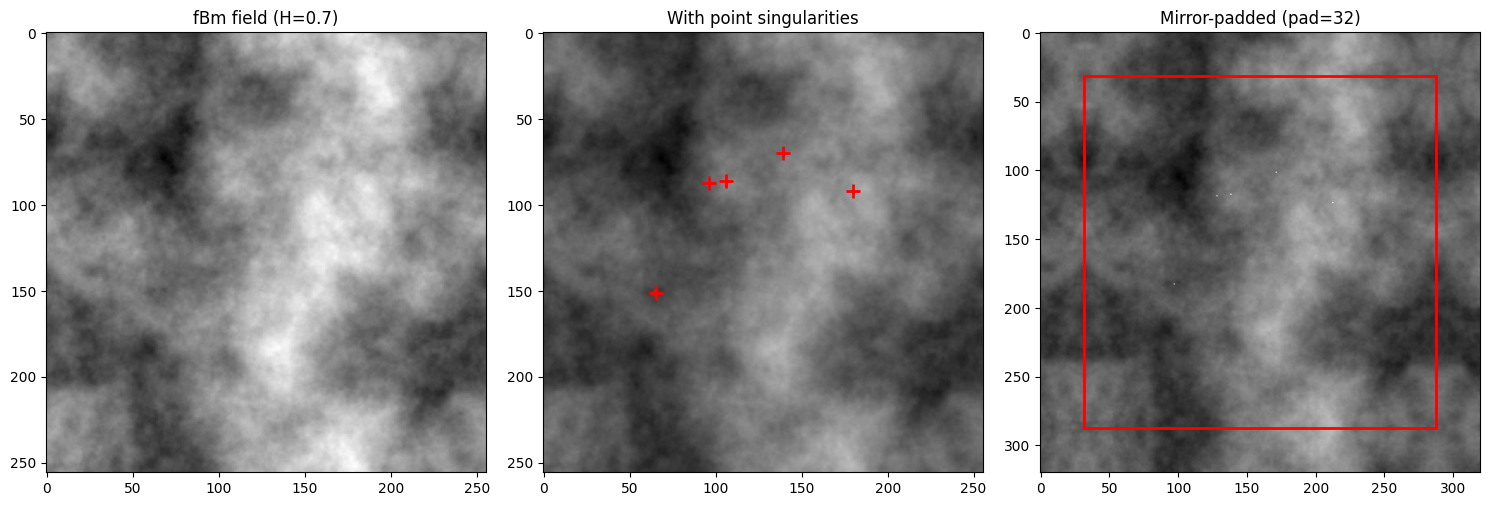

In [ ]:
def generate_fbm_2d(N, H=0.5, seed=42):
    """Generate 2D fractional Brownian field with Hurst exponent H.
    
    Power spectrum P(k) ~ |k|^{-(2H+2)} in 2D.
    """
    rng = np.random.default_rng(seed)
    
    # Frequency grids
    kx = fftfreq(N, d=1.0/N)
    ky = fftfreq(N, d=1.0/N)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    K[0, 0] = 1.0  # avoid division by zero
    
    # Power spectrum amplitude
    amplitude = K ** (-(H + 1.0))  # 2D: exponent = -(2H+2)/2 = -(H+1)
    amplitude[0, 0] = 0.0
    
    # Random phases
    phases = rng.uniform(0, 2*np.pi, (N, N))
    
    # Build spectrum and enforce Hermitian symmetry
    spectrum = amplitude * np.exp(1j * phases)
    field = np.real(np.fft.ifft2(spectrum))
    
    # Normalize to [0, 1]
    field = (field - field.min()) / (field.max() - field.min())
    return field

def add_point_singularities(field, n_points=5, seed=123):
    """Add point singularities (Dirac-like peaks) to test detection."""
    rng = np.random.default_rng(seed)
    N = field.shape[0]
    result = field.copy()
    positions = []
    for _ in range(n_points):
        x, y = rng.integers(N//4, 3*N//4, size=2)
        result[y, x] += 3.0 * field.std()
        positions.append((x, y))
    return result, positions

def mirror_pad_image(image, pad_width):
    """Mirror-pad image to eliminate periodic FFT border artifacts.
    
    Follows xsmurf cv2d_n.c border handling: reflect at boundaries so the
    periodic assumption of FFT doesn't create artificial edge maxima.
    
    Returns:
        padded: mirror-padded image
        crop_slice: tuple of slices to extract the center (original) region
    """
    padded = np.pad(image, pad_width, mode='reflect')
    crop_slice = (slice(pad_width, pad_width + image.shape[0]),
                  slice(pad_width, pad_width + image.shape[1]))
    return padded, crop_slice

# Generate test image
N = 256  # Image size (power of 2 for FFT efficiency)
H_true = 0.7  # Known Hurst exponent

field = generate_fbm_2d(N, H=H_true)
field_with_singularities, sing_positions = add_point_singularities(field)

# Also try loading a real image if available
try:
    from PIL import Image
    import os
    for path in ['/usr/local/share/images/lena.png', 
                 os.path.expanduser('~/Pictures/lena.png')]:
        if os.path.exists(path):
            img = np.array(Image.open(path).convert('L').resize((N, N)), dtype=np.float64)
            img = img / 255.0
            print(f"Loaded real image from {path}")
            break
    else:
        img = None
except ImportError:
    img = None

# Use the fBm field as our test image
test_image = field_with_singularities

# Mirror-pad by largest scale radius to avoid FFT edge artifacts
# Pad width = ceil(max_scale * wavelet_support), we'll use ~32 pixels
PAD_WIDTH = 32
test_image_padded, crop_slice = mirror_pad_image(test_image, PAD_WIDTH)

print(f"Test image shape: {test_image.shape}")
print(f"Padded shape:     {test_image_padded.shape} (pad={PAD_WIDTH})")
print(f"Crop slice:       {crop_slice}")
print(f"True Hurst exponent: H = {H_true}")
print(f"Added {len(sing_positions)} point singularities")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(field, cmap='gray')
axes[0].set_title(f'fBm field (H={H_true})')
axes[1].imshow(test_image, cmap='gray')
for x, y in sing_positions:
    axes[1].plot(x, y, 'r+', markersize=10, markeredgewidth=2)
axes[1].set_title('With point singularities')
axes[2].imshow(test_image_padded, cmap='gray')
# Draw rectangle showing original region
rect = plt.Rectangle((PAD_WIDTH - 0.5, PAD_WIDTH - 0.5), N, N,
                      linewidth=2, edgecolor='red', facecolor='none')
axes[2].add_patch(rect)
axes[2].set_title(f'Mirror-padded (pad={PAD_WIDTH})')
plt.tight_layout()
plt.show()

## 2. Wavelet Definitions (from xsmurf `wt.tcl`)

The 2D gradient wavelet uses partial derivatives of Gaussian in Fourier domain:
- ψ_x(kx, ky) = i·kx · exp(-(kx² + ky²)/2)  
- ψ_y(kx, ky) = i·ky · exp(-(kx² + ky²)/2)

At scale `a`, the dilated wavelet in Fourier domain is:
- ψ̂_x(a·kx, a·ky) = i·(a·kx) · exp(-a²(kx² + ky²)/2)

In [ ]:
def gaussian_derivative_wavelet_2d_fourier(kx_grid, ky_grid, scale):
    """
    Compute 2D Gaussian derivative wavelets in Fourier domain using MLX.

    From xsmurf wt.tcl:
        __conv_dx: Fourier form '0, x*exp(-x*x-y*y)'
        __conv_dy: Fourier form '0, y*exp(-x*x-y*y)'

    kx_grid, ky_grid: MLX arrays (frequency grids)
    scale: float

    Returns:
        psi_x_hat, psi_y_hat: MLX complex64 arrays (Fourier domain wavelet filters)
    """
    akx = scale * kx_grid
    aky = scale * ky_grid

    # Gaussian envelope in Fourier domain
    gauss = mx.exp(-(akx * akx + aky * aky))

    # Derivative wavelets: i*k*exp(-k^2)
    # MLX complex: build real=0, imag=ak*gauss
    zeros = mx.zeros_like(gauss)
    psi_x_hat = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                    np.array(akx * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    psi_y_hat = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                    np.array(aky * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)

    return psi_x_hat, psi_y_hat

def higher_order_wavelets_2d_fourier(kx_grid, ky_grid, scale):
    """
    Higher-order derivative wavelets for tensor analysis (MLX version).

    From xsmurf wt.tcl:
        __conv_dxx: '-(2*x*x-1)*exp(-x*x-y*y), 0'
        __conv_dxy: '-2*x*y*exp(-x*x-y*y), 0'
        __conv_dyy: '-(2*y*y-1)*exp(-x*x-y*y), 0'

    Returns:
        psi_xx_hat, psi_xy_hat, psi_yy_hat: MLX complex64 arrays
    """
    akx = scale * kx_grid
    aky = scale * ky_grid
    gauss = mx.exp(-(akx * akx + aky * aky))

    # Second derivatives in Fourier domain: multiply by -k_i*k_j
    psi_xx_np = np.array(-akx * akx * gauss)
    psi_xy_np = np.array(-akx * aky * gauss)
    psi_yy_np = np.array(-aky * aky * gauss)

    def to_complex(real_part):
        return mx.array(np.stack([real_part, np.zeros_like(real_part)], axis=-1)).view(mx.complex64).squeeze(-1)

    return to_complex(psi_xx_np), to_complex(psi_xy_np), to_complex(psi_yy_np)

def third_order_wavelets_2d_fourier(kx_grid, ky_grid, scale):
    """
    Third-order derivative wavelets for kapa'/kapap computation (MLX version).

    From xsmurf wt.tcl:
        __conv_dxxx: Fourier form '0, -x*(2*x*x-3)*exp(-x*x-y*y)'
        __conv_dxxy: Fourier form '0, -y*(2*x*x-1)*exp(-x*x-y*y)'
        __conv_dxyy: Fourier form '0, -x*(2*y*y-1)*exp(-x*x-y*y)'
        __conv_dyyy: Fourier form '0, -y*(2*y*y-3)*exp(-x*x-y*y)'

    In Fourier domain: i * k_i * k_j * k_k * gauss (imaginary, odd-order).

    Returns:
        psi_xxx, psi_xxy, psi_xyy, psi_yyy: MLX complex64 arrays
    """
    akx = scale * kx_grid
    aky = scale * ky_grid
    gauss = mx.exp(-(akx * akx + aky * aky))

    # Third derivatives: imaginary part = k_i*k_j*k_k * gauss
    xxx_np = np.array(akx * akx * akx * gauss)
    xxy_np = np.array(akx * akx * aky * gauss)
    xyy_np = np.array(akx * aky * aky * gauss)
    yyy_np = np.array(aky * aky * aky * gauss)

    def to_complex_imag(imag_part):
        return mx.array(np.stack([np.zeros_like(imag_part), imag_part], axis=-1)).view(mx.complex64).squeeze(-1)

    return to_complex_imag(xxx_np), to_complex_imag(xxy_np), to_complex_imag(xyy_np), to_complex_imag(yyy_np)

print("Wavelet definitions loaded (MLX arrays).")
print("  - gaussian_derivative_wavelet_2d_fourier: psi_x, psi_y (gradient)")
print("  - higher_order_wavelets_2d_fourier: psi_xx, psi_xy, psi_yy (Hessian)")
print("  - third_order_wavelets_2d_fourier: psi_xxx, psi_xxy, psi_xyy, psi_yyy (for kapa/kapap)")

Wavelet definitions loaded (MLX arrays).
  - gaussian_derivative_wavelet_2d_fourier: psi_x, psi_y (gradient)
  - higher_order_wavelets_2d_fourier: psi_xx, psi_xy, psi_yy (Hessian)
  - third_order_wavelets_2d_fourier: psi_xxx, psi_xxy, psi_xyy, psi_yyy (for kapa/kapap)


## 3. FFT-based 2D Continuous Wavelet Transform

Implements the CWT via multiplication in Fourier domain, following xsmurf's
`cv2d_a_real_ft` method: FFT(image) × ψ̂(a·k) → IFFT → wavelet coefficients.

Scale sequence from xsmurf: `a = a_min * 2^(oct + vox/n_vox)`

In [ ]:
def compute_scales(n_octaves, n_voices, a_min=1.0):
    """
    Generate scale sequence following xsmurf convention.
    
    From xsmurf wt.tcl:
        scale = a_min * pow(2, oct + vox/n_vox) * (6/0.86)
    
    The factor 6/0.86 ~ 6.977 normalizes the Gaussian wavelet support.
    """
    scales = []
    scale_labels = []
    norm_factor = 6.0 / 0.86  # xsmurf normalization
    
    for oct in range(n_octaves):
        for vox in range(n_voices):
            s = a_min * (2.0 ** (oct + vox / n_voices)) * norm_factor
            scales.append(s)
            scale_labels.append(f"o{oct}v{vox}")
    
    return np.array(scales), scale_labels

def cwt_2d(padded_image, scales, crop_slice):
    """
    2D Continuous Wavelet Transform using MLX GPU FFT with mirror-padded input.
    
    For each scale, computes:
        W_x[a](x,y) = (f * psi_x^a)(x,y)  (x-derivative component)
        W_y[a](x,y) = (f * psi_y^a)(x,y)  (y-derivative component)
    
    The input is the mirror-padded image. After IFFT, the center region
    (crop_slice) is extracted to remove border artifacts.
    
    Returns:
        wx: array (n_scales, ny_orig, nx_orig) - x-component (numpy)
        wy: array (n_scales, ny_orig, nx_orig) - y-component (numpy)
    """
    ny_pad, nx_pad = padded_image.shape
    n_scales = len(scales)
    
    # Original (cropped) dimensions
    ny_orig = crop_slice[0].stop - crop_slice[0].start
    nx_orig = crop_slice[1].stop - crop_slice[1].start
    
    # Frequency grids (numpy for fftfreq, then convert to MLX)
    kx_np = fftfreq(nx_pad) * 2 * np.pi  # angular frequency
    ky_np = fftfreq(ny_pad) * 2 * np.pi
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX = mx.array(KX_np.astype(np.float32))
    KY = mx.array(KY_np.astype(np.float32))
    
    # FFT of padded image (done once, on GPU)
    image_mx = mx.array(padded_image.astype(np.float32))
    image_fft = mx.fft.fft2(image_mx)
    
    # Allocate output (original size, after cropping)
    wx = np.zeros((n_scales, ny_orig, nx_orig), dtype=np.float64)
    wy = np.zeros((n_scales, ny_orig, nx_orig), dtype=np.float64)
    
    for i, scale in enumerate(scales):
        # Get wavelet filters in Fourier domain (MLX complex arrays)
        psi_x, psi_y = gaussian_derivative_wavelet_2d_fourier(KX, KY, scale)
        
        # Convolve: multiply in Fourier domain, then IFFT
        # Use conjugate for convolution (not correlation)
        wx_full = mx.fft.ifft2(image_fft * mx.conj(psi_x))
        wy_full = mx.fft.ifft2(image_fft * mx.conj(psi_y))
        
        # Convert to numpy real, then crop center region
        # MLX: .real is a property, not a method
        wx_np = np.array(wx_full.real.astype(mx.float32))
        wy_np = np.array(wy_full.real.astype(mx.float32))
        
        wx[i] = wx_np[crop_slice]
        wy[i] = wy_np[crop_slice]
    
    return wx, wy


def cwt_2d_all_derivatives(padded_image, scales, crop_slice):
    """
    2D CWT computing ALL derivatives needed for kapa/kapap WTMM detection.

    Returns dx, dy (1st order), dxx, dxy, dyy (2nd order),
    dxxx, dxxy, dxyy, dyyy (3rd order) at each scale.

    These are used by the derivative-based WTMM method (useNMaxSup=0 in xsmurf):
      kapa  = 2*dx^2*dxx + 4*dxy*dx*dy + 2*dy^2*dyy
      kapap = dx^2*(4*(dxx^2+dxy^2) + 2*dx*dxxx + 6*dy*dxxy)
            + dy^2*(4*(dyy^2+dxy^2) + 2*dy*dyyy + 6*dx*dxyy)
            + 8*dx*dy*dxy*(dxx+dyy)
    """
    ny_pad, nx_pad = padded_image.shape
    n_scales = len(scales)
    ny_orig = crop_slice[0].stop - crop_slice[0].start
    nx_orig = crop_slice[1].stop - crop_slice[1].start

    kx_np = fftfreq(nx_pad) * 2 * np.pi
    ky_np = fftfreq(ny_pad) * 2 * np.pi
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX = mx.array(KX_np.astype(np.float32))
    KY = mx.array(KY_np.astype(np.float32))

    image_mx = mx.array(padded_image.astype(np.float32))
    image_fft = mx.fft.fft2(image_mx)

    # Output arrays: [n_scales, ny, nx]
    names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    result = {n: np.zeros((n_scales, ny_orig, nx_orig), dtype=np.float64) for n in names}

    for i, scale in enumerate(scales):
        psi_x, psi_y = gaussian_derivative_wavelet_2d_fourier(KX, KY, scale)
        psi_xx, psi_xy, psi_yy = higher_order_wavelets_2d_fourier(KX, KY, scale)
        psi_xxx, psi_xxy, psi_xyy, psi_yyy = third_order_wavelets_2d_fourier(KX, KY, scale)

        for name, psi in [('dx', psi_x), ('dy', psi_y),
                          ('dxx', psi_xx), ('dxy', psi_xy), ('dyy', psi_yy),
                          ('dxxx', psi_xxx), ('dxxy', psi_xxy),
                          ('dxyy', psi_xyy), ('dyyy', psi_yyy)]:
            conv = mx.fft.ifft2(image_fft * mx.conj(psi))
            result[name][i] = np.array(conv.real.astype(mx.float32))[crop_slice]

    return result

# Compute CWT
n_octaves = 4
n_voices = 4
scales, scale_labels = compute_scales(n_octaves, n_voices, a_min=1.0)

print(f"Computing 2D CWT with {len(scales)} scales (MLX GPU FFT)...")
print(f"Scale range: [{scales[0]:.2f}, {scales[-1]:.2f}]")
print(f"Input: padded image {test_image_padded.shape} -> crop to {test_image.shape}")

wx, wy = cwt_2d(test_image_padded, scales, crop_slice)
print(f"CWT shape: wx={wx.shape}, wy={wy.shape}")
print("Done.")

Computing 2D CWT with 16 scales (MLX GPU FFT)...
Scale range: [6.98, 93.87]


Error: Error: NameError: name 'test_image_padded' is not defined
[31m---------------------------------------------------------------------------[39m
[31mNameError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[6][39m[32m, line 131[39m
[32m    129[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mComputing 2D CWT with [39m[38;5;132;01m{[39;00m[38;5;28mlen[39m(scales)[38;5;132;01m}[39;00m[33m scales (MLX GPU FFT)...[39m[33m"[39m)
[32m    130[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mScale range: [[39m[38;5;132;01m{[39;00mscales[[32m0[39m][38;5;132;01m:[39;00m[33m.2f[39m[38;5;132;01m}[39;00m[33m, [39m[38;5;132;01m{[39;00mscales[-[32m1[39m][38;5;132;01m:[39;00m[33m.2f[39m[38;5;132;01m}[39;00m[33m][39m[33m"[39m)
[32m--> [39m[32m131[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mInput: padded image [39m[38;5;132;01m{[39;00m[43mtest_image_padded[49m.shape[38;5;13

## 4. Gradient Modulus & Argument (from `edge/misc.c`)

Direct port of `GradientModulus2D` and `GradientArgument2D`:
- modulus = sqrt(wx² + wy²)
- argument = atan2(wy, wx), with special value 10.0 for near-zero gradient

Modulus shape: (16, 256, 256)
Modulus range at scale 0: [0.000003, 0.101650]


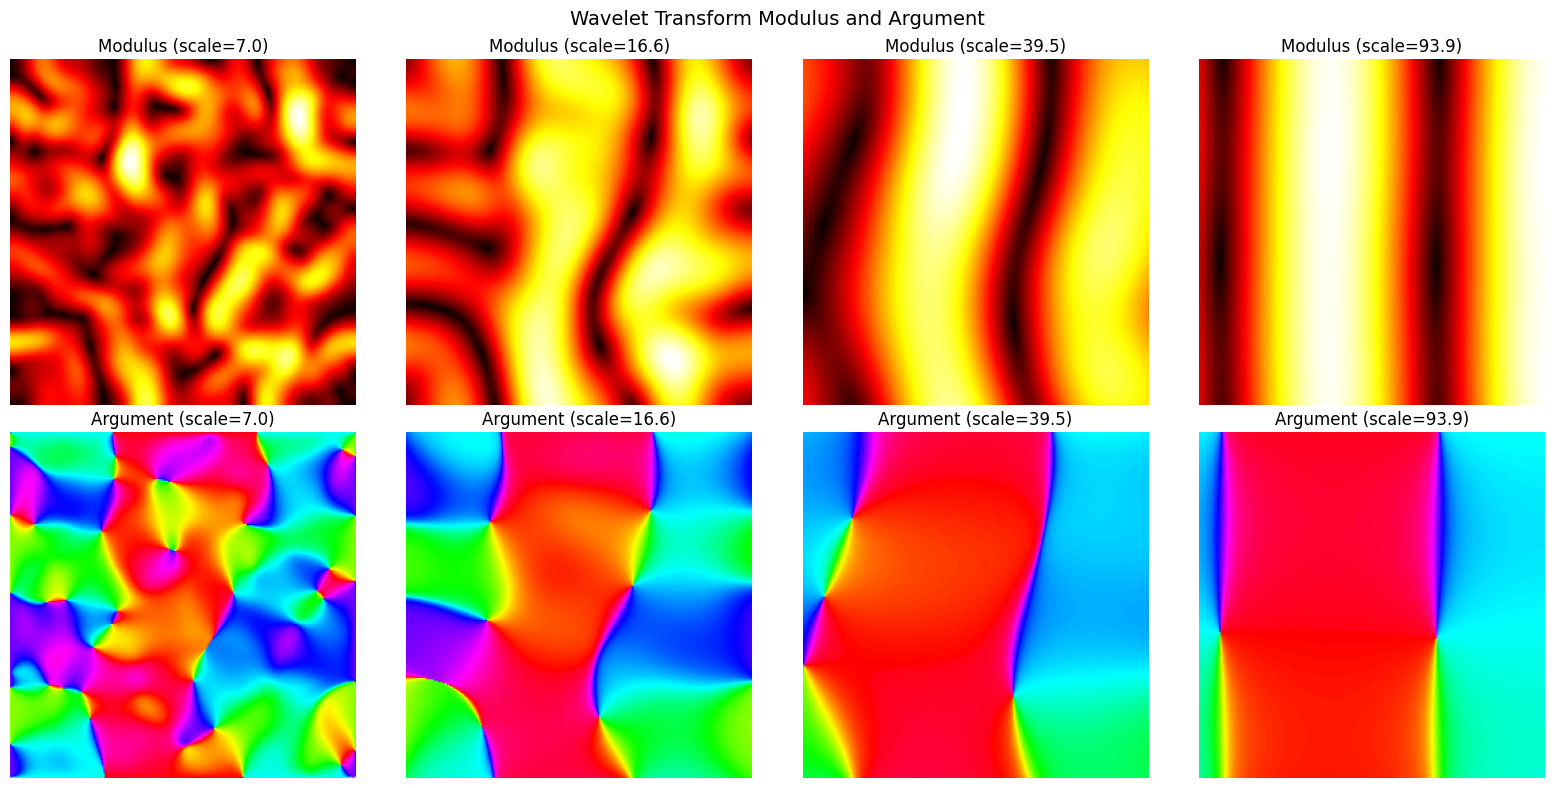

In [ ]:
def gradient_modulus_2d(wx, wy):
    """
    Port of xsmurf GradientModulus2D (edge/misc.c).
    
    modulus = sqrt(gx*gx + gy*gy)
    """
    return np.sqrt(wx**2 + wy**2)

def gradient_argument_2d(wx, wy, eps=1e-6):
    """
    Port of xsmurf GradientArgument2D (edge/misc.c).
    
    argument = atan2(gy, gx) if gradient is large enough, else 10.0
    """
    norm_sq = wx**2 + wy**2
    arg = np.where(norm_sq > eps**2, np.arctan2(wy, wx), 10.0)
    return arg

# Compute modulus and argument at all scales
modulus = gradient_modulus_2d(wx, wy)
argument = gradient_argument_2d(wx, wy)

print(f"Modulus shape: {modulus.shape}")
print(f"Modulus range at scale 0: [{modulus[0].min():.6f}, {modulus[0].max():.6f}]")

# Visualize a few scales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
display_indices = np.linspace(0, len(scales)-1, 4, dtype=int)
for col, idx in enumerate(display_indices):
    axes[0, col].imshow(modulus[idx], cmap='hot')
    axes[0, col].set_title(f'Modulus (scale={scales[idx]:.1f})')
    axes[0, col].axis('off')
    
    # Show argument only where modulus is significant
    arg_display = np.where(argument[idx] < 5, argument[idx], np.nan)
    axes[1, col].imshow(arg_display, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    axes[1, col].set_title(f'Argument (scale={scales[idx]:.1f})')
    axes[1, col].axis('off')

plt.suptitle('Wavelet Transform Modulus and Argument', fontsize=14)
plt.tight_layout()
plt.show()

## 5. WTMM Point Detection

Two methods are available (matching xsmurf's `useNMaxSup` flag):

**Method 1 (default, `useNMaxSup=0`)**: Derivative-based using kapa/kapap.
Computes directional derivatives of gradient modulus (kapa = 1st, kapap = 2nd).
WTMM points are where kapa crosses zero (near_contour_line) AND kapap < 0 (maximum not minimum).
Uses `follow` command in xsmurf (`w2_folow_contour` in `wt2d/Extrema.c`).

**Method 2 (`useNMaxSup=1`)**: Non-maxima suppression (NMS).
Port of `Remove_Gradient_NonMaxima_Slice_2D` from `edge/extrema_core.c`.
For each pixel, compares gradient modulus with bilinear-interpolated values
along and against the gradient direction.

Set `WTMM_METHOD = 'follow'` or `'nms'` below.

In [ ]:
WTMM_METHOD = 'follow'  # 'follow' (derivative-based) or 'nms' (non-maxima suppression)

def non_maxima_suppression_2d(gx, gy, norme, eps_norm=5e-7, eps_deriv=0.9995):
    """
    Port of xsmurf Remove_Gradient_NonMaxima_Slice_2D (edge/extrema_core.c).

    Non-maxima suppression along gradient direction using bilinear interpolation.
    """
    ny, nx = norme.shape
    maxima = np.zeros_like(norme)

    for y in range(1, ny - 1):
        for x in range(1, nx - 1):
            n = norme[y, x]
            if n < eps_norm:
                continue

            ngx = gx[y, x] / n
            ngy = gy[y, x] / n

            if (abs(ngx) > eps_deriv or abs(ngy) > eps_deriv):
                xi = int(x + ngx + 0.5)
                yi = int(y + ngy + 0.5)
                if 0 <= xi < nx and 0 <= yi < ny:
                    if n <= norme[yi, xi]:
                        continue
                xi = int(x - ngx + 0.5)
                yi = int(y - ngy + 0.5)
                if 0 <= xi < nx and 0 <= yi < ny:
                    if n < norme[yi, xi]:
                        continue
                maxima[y, x] = n
                continue

            xf = x + ngx
            yf = y + ngy
            if xf < 0 or xf >= nx - 1 or yf < 0 or yf >= ny - 1:
                continue

            x0 = int(xf)
            y0 = int(yf)
            dx = xf - x0
            dy = yf - y0
            dxdy = dx * dy
            c00 = 1.0 - dx - dy + dxdy
            c10 = dx - dxdy
            c01 = dy - dxdy
            c11 = dxdy

            interp_forward = (norme[y0, x0] * c00 +
                            norme[y0, x0+1] * c10 +
                            norme[y0+1, x0] * c01 +
                            norme[y0+1, x0+1] * c11)

            if n <= interp_forward:
                continue

            xb = x - ngx
            yb = y - ngy
            if xb < 0 or xb >= nx - 1 or yb < 0 or yb >= ny - 1:
                continue

            x0b = int(xb)
            y0b = int(yb)
            interp_backward = (norme[y0b, x0b] * c11 +
                              norme[y0b, x0b+1] * c01 +
                              norme[y0b+1, x0b] * c10 +
                              norme[y0b+1, x0b+1] * c00)

            if n < interp_backward:
                continue

            maxima[y, x] = n

    return maxima


def compute_kapa_kapap(dx, dy, dxx, dxy, dyy, dxxx, dxxy, dxyy, dyyy):
    """
    Port of xsmurf gkapa and gkapap from wt2d_cmds.c.

    kapa = directional derivative of gradient modulus along gradient direction.
    kapap = second directional derivative (for max vs min discrimination).
    """
    kapa = 2*dx*dx*dxx + 4*dxy*dx*dy + 2*dy*dy*dyy

    kapap = (dx*dx*(4*(dxx*dxx + dxy*dxy) + 2*dx*dxxx + 6*dy*dxxy)
           + dy*dy*(4*(dyy*dyy + dxy*dxy) + 2*dy*dyyy + 6*dx*dxyy)
           + 8*dx*dy*dxy*(dxx + dyy))

    return kapa, kapap


def follow_contour_2d(kapa, kapap):
    """
    Port of w2_folow_contour from wt2d/Extrema.c.

    Find WTMM points as zero-crossings of kapa where kapap < 0.
    A pixel is a WTMM point if:
      1. kapap[y,x] < 0 (concave = maximum, not minimum)
      2. near_contour_line: kapa changes sign with a cardinal neighbor (N,E,S,W)
         AND this pixel is closer to the zero-crossing (|kapa| < |kapa_neighbor|)
    """
    ny, nx = kapa.shape
    maxima = np.zeros((ny, nx), dtype=np.float64)

    # Cardinal neighbor offsets (matching xsmurf pos_incr for odd indices: N,E,S,W)
    cardinal_dy = [-1, 0, 1, 0]
    cardinal_dx = [0, 1, 0, -1]

    for y in range(1, ny - 1):
        for x in range(1, nx - 1):
            if kapap[y, x] >= 0:
                continue

            # Check near_contour_line: kapa changes sign with a cardinal neighbor
            # and this pixel is closer to zero
            kval = kapa[y, x]
            is_near = False
            for di in range(4):
                ny2 = y + cardinal_dy[di]
                nx2 = x + cardinal_dx[di]
                kn = kapa[ny2, nx2]
                if kval * kn < 0 and abs(kval) < abs(kn):
                    is_near = True
                    break

            if is_near:
                maxima[y, x] = 1.0  # mark as WTMM point (modulus filled later)

    return maxima


# Compute extrema using selected method
if WTMM_METHOD == 'follow':
    print("Computing higher-order derivatives for kapa/kapap method...")
    deriv = cwt_2d_all_derivatives(test_image_padded, scales, crop_slice)

    print("Computing WTMM points via kapa/kapap zero-crossing (follow method)...")
    extrema_maps = np.zeros_like(modulus)
    for i in range(len(scales)):
        kapa, kapap = compute_kapa_kapap(
            deriv['dx'][i], deriv['dy'][i],
            deriv['dxx'][i], deriv['dxy'][i], deriv['dyy'][i],
            deriv['dxxx'][i], deriv['dxxy'][i], deriv['dxyy'][i], deriv['dyyy'][i])

        mask = follow_contour_2d(kapa, kapap)
        # Fill in modulus values at detected points
        extrema_maps[i] = mask * modulus[i]

        if (i + 1) % 5 == 0:
            n_ext = np.count_nonzero(extrema_maps[i])
            print(f"  Scale {i}: {n_ext} extrema found")
else:
    print("Computing WTMM points via non-maxima suppression (NMS method)...")
    extrema_maps = np.zeros_like(modulus)
    for i in range(len(scales)):
        extrema_maps[i] = non_maxima_suppression_2d(wx[i], wy[i], modulus[i])
        if (i + 1) % 5 == 0:
            n_ext = np.count_nonzero(extrema_maps[i])
            print(f"  Scale {i}: {n_ext} extrema found")

print(f"WTMM method: {WTMM_METHOD}")
print(f"Total extrema across all scales: {np.count_nonzero(extrema_maps)}")

Computing higher-order derivatives for kapa/kapap method...
Computing WTMM points via kapa/kapap zero-crossing (follow method)...
  Scale 4: 77 extrema found
  Scale 9: 0 extrema found
  Scale 14: 0 extrema found
WTMM method: follow
Total extrema across all scales: 828


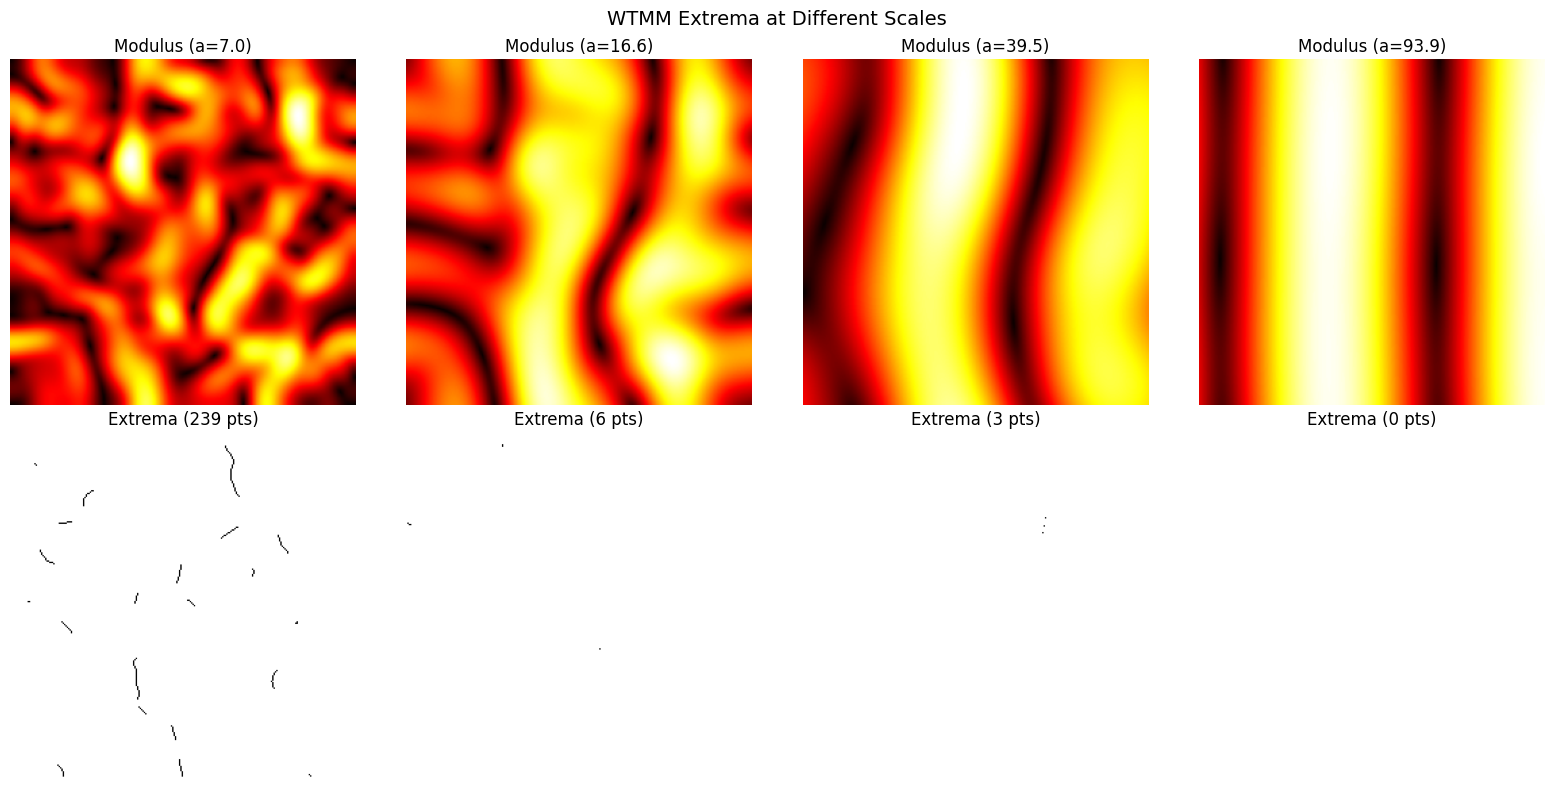

In [ ]:
# Visualize extrema at selected scales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
display_indices = np.linspace(0, len(scales)-1, 4, dtype=int)

for col, idx in enumerate(display_indices):
    # Modulus
    axes[0, col].imshow(modulus[idx], cmap='hot')
    axes[0, col].set_title(f'Modulus (a={scales[idx]:.1f})')
    axes[0, col].axis('off')
    
    # Extrema (skeleton lines)
    ext_display = np.where(extrema_maps[idx] > 0, 1.0, 0.0)
    axes[1, col].imshow(ext_display, cmap='gray_r')
    n_ext = np.count_nonzero(extrema_maps[idx])
    axes[1, col].set_title(f'Extrema ({n_ext} pts)')
    axes[1, col].axis('off')

plt.suptitle('WTMM Extrema at Different Scales', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Chain Extraction + Vertical Chaining (port of xsmurf TCL pipeline)

From `tcl_library/eiChain.tcl`, the actual xsmurf pipeline per scale is:
```
hsearch $zeEi                              -> search_lines() from chain.c
ssm $zeEi                                  -> search_single_max() from single_max.c
boxSize = int(boxRatio * log(scale) * 2 / log(2))
vchain $prevEi $zeEi $boxSize $similitude  -> vert_chain() from chain2.c
```

**search_lines** (`chain.c`): 8-connected depth-first walk.
- Pass 1 (repeated): Start from line endpoints (<=2 neighbors). Greedy walk following one neighbor at a time (priority: W,N,S,E,NW,SW,NE,SE).
- Pass 2: Pick up remaining (closed loops).
- Check if closed (first/last extrema are 8-adjacent).

**search_single_max** (`single_max.c`): Find local modulus maxima along chains.
An extremum is a "single max" if it has exactly 2 clockwise neighbor transitions
(extremum->non-extremum) AND its modulus >= all 8 neighbors. Stored in `line.gr_lst`.

**vert_chain** (`chain2.c:371-486`): Cross-scale linking using:
- Scale-dependent box search: `box_size = int(log(scale) * 2 / log(2))`
- Modulus ratio constraint: `similitude < mod_coarse/mod_fine < 1/similitude` (similitude=0.8)
- Distance constraint: `dist^2 < 50`
- Competition: if coarse extremum already linked, keep the closer one
- Only processes `gr_lst` extrema (single maxima), not all extrema
- `-first` flag on first scale: all extrema eligible; subsequent scales: only those with existing `down` link

In [ ]:
class Extremum:
    """Port of xsmurf Extremum struct (wt2d/extremum.h)."""
    __slots__ = ['pos', 'x', 'y', 'mod', 'arg', 'ord', 'scale_idx',
                 'line_id', 'surface_id', 'prev', 'next', 'up', 'down',
                 'ext_idx']

    def __init__(self, x, y, mod, arg, scale_idx, ext_idx, lx):
        self.x = x
        self.y = y
        self.pos = y * lx + x  # linear position (uses actual image width)
        self.mod = mod
        self.arg = arg
        self.ord = mod  # ordinate for partition function
        self.scale_idx = scale_idx
        self.ext_idx = ext_idx
        self.line_id = -1
        self.surface_id = -1
        self.prev = None
        self.next = None
        self.up = None    # link to coarser scale extremum
        self.down = None  # link to finer scale extremum

class Line:
    """Port of xsmurf Line struct. A connected chain of extrema at one scale."""
    def __init__(self, line_id, scale_idx):
        self.line_id = line_id
        self.scale_idx = scale_idx
        self.extrema = []  # list of Extremum objects, ORDERED along chain
        self.max_mod = 0.0
        self.mass = 0.0
        self.is_closed = False
        self.gr_lst = []  # local maxima of modulus along chain (single_max)

    def add_extremum(self, ext):
        self.extrema.append(ext)
        ext.line_id = self.line_id
        self.mass += ext.mod
        if ext.mod > self.max_mod:
            self.max_mod = ext.mod

class ExtImage:
    """Port of xsmurf ExtImage. All extrema and lines at one scale."""
    def __init__(self, scale_idx, scale, lx, ly):
        self.scale_idx = scale_idx
        self.scale = scale
        self.lx = lx
        self.ly = ly
        self.extrema = []
        self.lines = []
        # Per-extremum arrays for chain operations
        self.ext_x = None
        self.ext_y = None
        self.ext_mod = None
        self.ext_arg = None
        self.ext_ord = None
        self.coarser_link = None
        self.finer_link = None

    def build_arrays(self):
        n = len(self.extrema)
        self.ext_x = np.array([e.x for e in self.extrema], dtype=np.float64)
        self.ext_y = np.array([e.y for e in self.extrema], dtype=np.float64)
        self.ext_mod = np.array([e.mod for e in self.extrema], dtype=np.float64)
        self.ext_arg = np.array([e.arg for e in self.extrema], dtype=np.float64)
        self.ext_ord = np.array([e.ord for e in self.extrema], dtype=np.float64)
        self.coarser_link = np.full(n, -1, dtype=np.int64)
        self.finer_link = np.full(n, -1, dtype=np.int64)


# ========================================================================
# search_lines: Port of chain.c search_lines()
# ========================================================================

# Neighbor offsets matching chain.c iPosArray/jPosArray:
# Priority: W, N, S, E, NW, SW, NE, SE (cardinal first, then diagonal)
#            dx: -1,  0,  0,  1, -1,  1, -1,  1
#            dy:  0, -1,  1,  0, -1, -1,  1,  1
_NEIGHBOR_DX = [-1, 0, 0, 1, -1, -1, 1, 1]
_NEIGHBOR_DY = [0, -1, 1, 0, -1, 1, -1, 1]


def _nb_of_neighbors(ext_array, pos, lx, ly):
    """Count 8-connected extrema neighbors of position pos."""
    x = pos % lx
    y = pos // lx
    count = 0
    for k in range(8):
        nx = x + _NEIGHBOR_DX[k]
        ny = y + _NEIGHBOR_DY[k]
        if 0 <= nx < lx and 0 <= ny < ly and ext_array.get(nx + ny * lx) is not None:
            count += 1
    return count


def _is_line_end(ext_array, pos, lx, ly):
    """Port of _is_line_end_ from chain.c.

    A position is a line end if:
    - 0 or 1 neighbors, OR
    - exactly 2 neighbors that are cardinally adjacent to each other
    """
    x = pos % lx
    y = pos // lx
    nb = _nb_of_neighbors(ext_array, pos, lx, ly)

    if nb > 2:
        return False
    if nb <= 1:
        return True

    # Find the two neighbors
    neighbors = []
    for k in range(8):
        nx = x + _NEIGHBOR_DX[k]
        ny = y + _NEIGHBOR_DY[k]
        if 0 <= nx < lx and 0 <= ny < ly and ext_array.get(nx + ny * lx) is not None:
            neighbors.append((nx, ny))
            if len(neighbors) == 2:
                break

    # Check if the two neighbors are cardinally adjacent (manhattan dist = 1)
    (x1, y1), (x2, y2) = neighbors
    if (abs(x1 - x2) == 0 and abs(y1 - y2) == 1) or \
       (abs(x1 - x2) == 1 and abs(y1 - y2) == 0):
        return True

    return False


def _seek_neighbors_iterative(start_ext, ext_array, lx, ly):
    """Iterative version of _seek_neighbors_ from chain.c.

    Greedy walk: follow ONE neighbor at a time (first found in priority order).
    Returns ordered list of extrema in the chain (including start_ext).
    """
    chain = [start_ext]
    ext_array.pop(start_ext.pos, None)  # mark as used

    current = start_ext
    while True:
        x = current.pos % lx
        y = current.pos // lx
        found = None
        for k in range(8):
            nx = x + _NEIGHBOR_DX[k]
            ny = y + _NEIGHBOR_DY[k]
            if 0 <= nx < lx and 0 <= ny < ly:
                npos = nx + ny * lx
                ext = ext_array.get(npos)
                if ext is not None:
                    found = ext
                    ext_array.pop(npos)  # mark as used
                    break
        if found is None:
            break
        chain.append(found)
        current = found

    return chain


def _are_near(ext1, ext2, lx):
    """Check if two extrema are 8-adjacent. Port of _are_near_ from chain.c."""
    if ext1 is None or ext2 is None:
        return 0
    x1, y1 = ext1.pos % lx, ext1.pos // lx
    x2, y2 = ext2.pos % lx, ext2.pos // lx
    if abs(x1 - x2) <= 1 and abs(y1 - y2) <= 1:
        if abs(x1 - x2) * abs(y1 - y2) == 0:
            return 1  # cardinal
        return 2  # diagonal
    return 0


def _line_split(chain_exts, lx):
    """Port of _line_split_ from chain.c.

    Split a chain into connected sub-chains where consecutive extrema
    are 8-adjacent, then merge sub-chains whose endpoints touch.
    """
    if len(chain_exts) <= 1:
        return [chain_exts]

    # Split into connected sub-chains
    sub_chains = []
    current = [chain_exts[0]]
    for i in range(1, len(chain_exts)):
        if _are_near(chain_exts[i], chain_exts[i-1], lx):
            current.append(chain_exts[i])
        else:
            sub_chains.append(current)
            current = [chain_exts[i]]
    sub_chains.append(current)

    if len(sub_chains) <= 1:
        return sub_chains

    # Merge sub-chains whose endpoints are 8-adjacent
    return _merge_sub_chains(sub_chains, lx)


def _merge_sub_chains(sub_chains, lx):
    """Port of _merge_line_array_ from chain.c.

    Recursively merge sub-chains whose endpoints are 8-adjacent.
    """
    merged = True
    while merged:
        merged = False
        i = 0
        while i < len(sub_chains):
            j = i + 1
            while j < len(sub_chains):
                meeting = _ends_meet(sub_chains[i], sub_chains[j], lx)
                if meeting is not None:
                    sub_chains[i] = _do_merge(sub_chains[i], sub_chains[j], meeting)
                    sub_chains.pop(j)
                    merged = True
                else:
                    j += 1
            i += 1
    return sub_chains


def _ends_meet(chain1, chain2, lx):
    """Check which endpoints of two chains are 8-adjacent."""
    if not chain1 or not chain2:
        return None
    b1, e1 = chain1[0], chain1[-1]
    b2, e2 = chain2[0], chain2[-1]

    # Cardinal first, then diagonal (matching xsmurf priority)
    for threshold in [1, 2]:
        if _are_near(b1, b2, lx) >= threshold:
            return 'BB'
        if _are_near(b1, e2, lx) >= threshold:
            return 'BE'
        if _are_near(e1, b2, lx) >= threshold:
            return 'EB'
        if _are_near(e1, e2, lx) >= threshold:
            return 'EE'
    return None


def _do_merge(chain1, chain2, meeting):
    """Merge two chains according to how their endpoints meet."""
    if meeting == 'BB':
        return list(reversed(chain2)) + chain1
    elif meeting == 'BE':
        return chain2 + chain1
    elif meeting == 'EB':
        return chain1 + chain2
    elif meeting == 'EE':
        return chain1 + list(reversed(chain2))
    return chain1


def search_lines(extrema_map, wx_scale, wy_scale, scale_idx, scale):
    """Port of search_lines() from chain.c.

    Two-pass chain extraction:
    Pass 1 (repeated): Start from line endpoints, greedy walk.
    Pass 2: Pick up remaining extrema (closed loops).
    """
    ny, nx = extrema_map.shape
    lx, ly = nx, ny
    ext_image = ExtImage(scale_idx, scale, lx, ly)

    # Create all Extremum objects and build spatial hash
    ext_array = {}  # pos -> Extremum
    all_extrema = []
    ext_idx = 0

    ext_positions = np.argwhere(extrema_map > 0)
    for row_y, col_x in ext_positions:
        arg = np.arctan2(wy_scale[row_y, col_x], wx_scale[row_y, col_x])
        ext = Extremum(col_x, row_y, extrema_map[row_y, col_x], arg,
                       scale_idx, ext_idx, lx)
        ext_array[ext.pos] = ext
        all_extrema.append(ext)
        ext_image.extrema.append(ext)
        ext_idx += 1

    if len(all_extrema) == 0:
        ext_image.build_arrays()
        return ext_image

    # Pass 1 (repeated): find lines starting from endpoints
    line_counter = 0
    while True:
        found_any = False
        # Scan all positions for endpoints
        positions = list(ext_array.keys())
        for pos in positions:
            if pos not in ext_array:
                continue
            if not _is_line_end(ext_array, pos, lx, ly):
                continue

            # Start a chain from this endpoint
            start_ext = ext_array[pos]
            chain_exts = _seek_neighbors_iterative(start_ext, ext_array, lx, ly)

            # Split disconnected fragments and merge touching endpoints
            sub_chains = _line_split(chain_exts, lx)

            for sub in sub_chains:
                if len(sub) == 0:
                    continue
                line = Line(line_counter, scale_idx)
                # Check if closed
                if len(sub) > 3 and _are_near(sub[0], sub[-1], lx):
                    line.is_closed = True
                for e in sub:
                    line.add_extremum(e)
                ext_image.lines.append(line)
                line_counter += 1

            found_any = True

        if not found_any:
            break

    # Pass 2: pick up remaining (closed loops, fragments)
    positions = list(ext_array.keys())
    for pos in positions:
        if pos not in ext_array:
            continue

        start_ext = ext_array[pos]
        chain_exts = _seek_neighbors_iterative(start_ext, ext_array, lx, ly)

        sub_chains = _line_split(chain_exts, lx)
        for sub in sub_chains:
            if len(sub) == 0:
                continue
            line = Line(line_counter, scale_idx)
            if len(sub) > 3 and _are_near(sub[0], sub[-1], lx):
                line.is_closed = True
            for e in sub:
                line.add_extremum(e)
            ext_image.lines.append(line)
            line_counter += 1

    # Build per-extremum arrays
    ext_image.build_arrays()
    return ext_image


# ========================================================================
# search_single_max: Port of single_max.c search_single_max()
# ========================================================================

# Clockwise neighbor offsets for single_max (from single_max.c):
#   0(-1,-1)  1(0,-1)  2(1,-1)
#   7(-1, 0)  9(0, 0)  3(1, 0)
#   6(-1, 1)  5(0, 1)  4(1, 1)
_SM_DX = [-1, 0, 1, 1, 1, 0, -1, -1, -1]  # pos_incr x-component (indices 0-8)
_SM_DY = [-1, -1, -1, 0, 1, 1, 1, 0, -1]  # pos_incr y-component


def _is_single_max(ext, ext_pos_set, all_ext_lookup, lx, ly):
    """Port of _is_single_max_ from single_max.c.

    An extremum is a single max if:
    1. It has exactly 2 clockwise "transitions" (neighbor is extremum but next
       clockwise neighbor is not). This means it sits on a thin line.
    2. Its modulus >= all 8 neighboring extrema.
    """
    x, y = ext.x, ext.y
    flag = 0

    for i in range(8):
        # Position of clockwise neighbor i
        nx1 = x + _SM_DX[i]
        ny1 = y + _SM_DY[i]
        # Position of next clockwise neighbor i+1
        nx2 = x + _SM_DX[i + 1]
        ny2 = y + _SM_DY[i + 1]

        pos1_valid = (0 <= nx1 < lx and 0 <= ny1 < ly)
        pos2_valid = (0 <= nx2 < lx and 0 <= ny2 < ly)

        pos1_is_ext = pos1_valid and (nx1 + ny1 * lx) in ext_pos_set
        pos2_is_ext = pos2_valid and (nx2 + ny2 * lx) in ext_pos_set

        # Transition: pos1 IS an extremum AND pos2 is NOT (or out of image)
        if pos1_is_ext and (not pos2_valid or not pos2_is_ext):
            flag += 1

    if flag != 2:
        return False

    # Check modulus >= all 8 neighbors
    for i in range(8):
        nx1 = x + _SM_DX[i]
        ny1 = y + _SM_DY[i]
        if 0 <= nx1 < lx and 0 <= ny1 < ly:
            npos = nx1 + ny1 * lx
            neighbor = all_ext_lookup.get(npos)
            if neighbor is not None and ext.mod < neighbor.mod:
                return False

    return True


def search_single_max(ext_image):
    """Port of search_single_max() from single_max.c.

    For each Line, find extrema that are local modulus maxima using spatial
    grid checks (not just chain ordering).
    """
    lx, ly = ext_image.lx, ext_image.ly

    # Build spatial lookup of ALL extrema positions
    ext_pos_set = set()
    all_ext_lookup = {}
    for ext in ext_image.extrema:
        ext_pos_set.add(ext.pos)
        all_ext_lookup[ext.pos] = ext

    for line in ext_image.lines:
        line.gr_lst = []
        for ext in line.extrema:
            if _is_single_max(ext, ext_pos_set, all_ext_lookup, lx, ly):
                line.gr_lst.append(ext)


# ========================================================================
# vert_chain: Port of vert_chain() from chain2.c:371-486
# ========================================================================

def vert_chain(do_ext_im, up_ext_im, box_size, arg_simil=0.8, is_first=False):
    """Port of vert_chain() from chain2.c:371-486.

    Link extrema from fine scale (do_ext_im) to coarse scale (up_ext_im).

    Uses gr_lst (single maxima) for both scales. For fine scale, only
    processes extrema that already have a 'down' link or is_first=True.

    Parameters:
        do_ext_im: ExtImage at finer scale
        up_ext_im: ExtImage at coarser scale
        box_size: search box half-size (scale-dependent)
        arg_simil: modulus ratio constraint (default 0.8)
        is_first: if True, all fine extrema are eligible (first scale)
    """
    lx = up_ext_im.lx
    ly = up_ext_im.ly

    # Build spatial array of coarser scale's gr_lst extrema
    up_array = {}  # pos -> Extremum
    for line in up_ext_im.lines:
        for ext in line.gr_lst:
            up_array[ext.pos] = ext

    # Collect fine-scale gr_lst extrema to process
    to_compute = []
    for line in do_ext_im.lines:
        for ext in line.gr_lst:
            if ext.down is not None or is_first:
                to_compute.append(ext)

    # For each fine extremum, search for closest coarse extremum in box
    for do_ext in to_compute:
        x0 = do_ext.pos % lx
        y0 = do_ext.pos // lx

        x_min = max(0, x0 - box_size)
        x_max = min(lx, x0 + box_size + 1)
        y_min = max(0, y0 - box_size)
        y_max = min(ly, y0 + box_size + 1)

        dist_min = 999999999
        tmp_ext = None

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                d = x + lx * y
                up_ext = up_array.get(d)
                if up_ext is not None:
                    dx = (d % lx) - (do_ext.pos % lx)
                    dy = (d // lx) - (do_ext.pos // lx)
                    dist = dx * dx + dy * dy

                    if do_ext.mod > 0:
                        mod_ratio = up_ext.mod / do_ext.mod
                    else:
                        continue

                    if (mod_ratio > arg_simil and mod_ratio < 1.0 / arg_simil
                            and dist < dist_min and dist < 50):
                        dist_min = dist
                        tmp_ext = up_ext

        # Link
        if tmp_ext is not None:
            if tmp_ext.down is not None:
                # Competition: compare distances
                old_dx = (do_ext.pos % lx) - (tmp_ext.pos % lx)
                old_dy = (do_ext.pos // lx) - (tmp_ext.pos // lx)
                dist1 = old_dx * old_dx + old_dy * old_dy

                prev_dx = (tmp_ext.down.pos % lx) - (tmp_ext.pos % lx)
                prev_dy = (tmp_ext.down.pos // lx) - (tmp_ext.pos // lx)
                dist2 = prev_dx * prev_dx + prev_dy * prev_dy

                if dist1 < dist2:
                    # New link is closer: break old, set new
                    tmp_ext.down.up = None
                    do_ext.up = tmp_ext
                    tmp_ext.down = do_ext
            else:
                do_ext.up = tmp_ext
                tmp_ext.down = do_ext


def _update_coarser_finer_links(ext_images):
    """After vert_chain, populate coarser_link/finer_link arrays from up/down pointers."""
    # Build ext_idx lookup per scale
    for si in range(len(ext_images)):
        ei = ext_images[si]
        ext_to_idx = {id(e): i for i, e in enumerate(ei.extrema)}

        for fi, ext in enumerate(ei.extrema):
            if ext.up is not None:
                # Find which scale the up-linked extremum is in
                for sj in range(len(ext_images)):
                    if sj == si:
                        continue
                    ej = ext_images[sj]
                    up_idx_map = {id(e): j for j, e in enumerate(ej.extrema)}
                    ci = up_idx_map.get(id(ext.up))
                    if ci is not None:
                        ei.coarser_link[fi] = ci
                        ej.finer_link[ci] = fi
                        break


# ========================================================================
# Execute: Pipeline matching xsmurf TCL orchestration
# ========================================================================

print("Extracting chains and vertical linking (xsmurf pipeline)...")
print("  Pipeline: search_lines -> search_single_max -> vert_chain")
print(f"  Similitude: 0.8, box_ratio: 1.0")

ext_images_ordered = []  # coarsest-first order
prev_ei = None

for i in range(len(scales) - 1, -1, -1):
    # Step 1: search_lines (8-connected walk from chain.c)
    ei = search_lines(extrema_maps[i], wx[i], wy[i], i, scales[i])

    # Step 2: search_single_max (spatial grid check from single_max.c)
    search_single_max(ei)

    # Step 3: vert_chain (box search from chain2.c)
    if prev_ei is not None:
        box_size = max(1, int(np.log(scales[i]) * 2.0 / np.log(2.0)))
        is_first_scale = (len(ext_images_ordered) == 1)  # second scale processed = first linking
        vert_chain(ei, prev_ei, box_size, arg_simil=0.8, is_first=is_first_scale)

    ext_images_ordered.append(ei)
    prev_ei = ei

    n_gr = sum(len(l.gr_lst) for l in ei.lines)
    if (len(scales) - i) % 5 == 0 or i == len(scales) - 1 or i == 0:
        box_s = max(1, int(np.log(scales[i]) * 2.0 / np.log(2.0)))
        print(f"  Scale {i:2d} (a={scales[i]:7.2f}): {len(ei.lines):4d} chains, "
              f"{len(ei.extrema):5d} extrema, {n_gr:4d} single_max, box={box_s}")

# Reverse to finest-first order
ext_images = list(reversed(ext_images_ordered))

# Populate coarser_link/finer_link arrays from up/down pointers
_update_coarser_finer_links(ext_images)

total_chains = sum(len(ei.lines) for ei in ext_images)
total_extrema = sum(len(ei.extrema) for ei in ext_images)
total_gr = sum(sum(len(l.gr_lst) for l in ei.lines) for ei in ext_images)
n_linked = sum(np.sum(ei.coarser_link >= 0) for ei in ext_images[:-1])

print(f"\nTotal: {total_chains} chains, {total_extrema} extrema, {total_gr} single_max")
print(f"Cross-scale links (via vert_chain): {n_linked}")

# Verify chain ordering
violations = 0
for ei in ext_images:
    for line in ei.lines:
        for j in range(len(line.extrema) - 1):
            e1, e2 = line.extrema[j], line.extrema[j + 1]
            if max(abs(e1.x - e2.x), abs(e1.y - e2.y)) > 1:
                violations += 1
print(f"Chain ordering violations (non-adjacent consecutive extrema): {violations}")

Extracting chains and vertical linking (xsmurf pipeline)...
  Pipeline: search_lines -> search_single_max -> vert_chain
  Similitude: 0.8, box_ratio: 1.0
  Scale 19 (a= 187.74):    0 chains,     0 extrema,    0 single_max, box=15
  Scale 15 (a=  93.87):    0 chains,     0 extrema,    0 single_max, box=13
  Scale 10 (a=  39.47):    3 chains,     3 extrema,    0 single_max, box=10
  Scale  5 (a=  16.59):    3 chains,     6 extrema,    0 single_max, box=8
  Scale  0 (a=   6.98):   21 chains,   239 extrema,    5 single_max, box=5

Total: 79 chains, 828 extrema, 12 single_max
Cross-scale links (via vert_chain): 0
Chain ordering violations (non-adjacent consecutive extrema): 0


## 7. Skeleton Construction (from `wt2d/vertical_chain.c`)

Surface-level grouping: link Lines across scales using proximity matching.
Per-extremum vertical links (`up`/`down` pointers, `coarser_link`/`finer_link` arrays)
are already set by `vert_chain()` in Cell 14.

`construct_skeleton()` builds Surfaces by matching Lines across scales using
the `proximity()` function (port of `_proxi_` from `vertical_chain.c`).

In [ ]:
class Surface:
    """Port of xsmurf Surface struct. A vertical chain of Lines across scales."""
    def __init__(self, surface_id):
        self.surface_id = surface_id
        self.lines = []  # ordered from coarsest to finest scale

    def add_line(self, line):
        self.lines.append(line)
        for ext in line.extrema:
            ext.surface_id = self.surface_id

    @property
    def smaller_scale_line(self):
        """The line at the finest (smallest) scale."""
        return self.lines[-1] if self.lines else None

    @property
    def n_scales(self):
        return len(self.lines)

def proximity(line1, line2, nx):
    """
    Port of xsmurf _proxi_ from vertical_chain.c.
    Count how many extrema in line1 are near (dist^2 <= 2) any extremum in line2.
    """
    count = 0
    for ext1 in line1.extrema:
        for ext2 in line2.extrema:
            dx = ext1.x - ext2.x
            dy = ext1.y - ext2.y
            if dx*dx + dy*dy <= 2:
                count += 1
                break
    return count

def find_nearest_line(line, candidate_lines, nx):
    """
    Port of xsmurf find_nearest_line from vertical_chain.c.
    Find the line in candidate_lines with highest proximity to the given line.
    """
    best_line = None
    best_prox = 0

    for cand in candidate_lines:
        prox = proximity(line, cand, nx)
        if prox > best_prox:
            best_prox = prox
            best_line = cand

    return best_line


def construct_skeleton(ext_images, nx, min_line_length=3):
    """
    Port of xsmurf construct_skeleton from vertical_chain.c.

    Scans scales from coarsest to finest, linking chains across scales.
    Per-extremum vertical links (up/down pointers, coarser_link/finer_link arrays)
    are already set by vert_chain() in Cell 14. This function builds
    Surface-level grouping of Lines across scales.
    """
    surfaces = []
    surface_counter = 0

    # Process from coarsest to finest scale
    ordered_images = list(reversed(ext_images))  # coarsest first

    prev_ext_image = None

    for ext_image in ordered_images:
        valid_lines = [l for l in ext_image.lines if len(l.extrema) >= min_line_length]

        if prev_ext_image is None:
            # Coarsest scale: create a surface for each line
            for line in valid_lines:
                surface = Surface(surface_counter)
                surface.add_line(line)
                surfaces.append(surface)
                surface_counter += 1
        else:
            prev_valid_lines = [l for l in prev_ext_image.lines
                               if len(l.extrema) >= min_line_length]

            linked_lines = set()

            # Build map from prev lines to surfaces
            prev_line_to_surface = {}
            for surf in surfaces:
                sl = surf.smaller_scale_line
                if sl is not None:
                    prev_line_to_surface[id(sl)] = surf

            # Candidate matching
            candidates = {}

            for line in valid_lines:
                nearest = find_nearest_line(line, prev_valid_lines, nx)
                if nearest is not None and id(nearest) in prev_line_to_surface:
                    surf = prev_line_to_surface[id(nearest)]
                    prox = proximity(line, nearest, nx)
                    if id(surf) not in candidates:
                        candidates[id(surf)] = []
                    candidates[id(surf)].append((line, prox, surf))
                else:
                    new_surf = Surface(surface_counter)
                    new_surf.add_line(line)
                    surfaces.append(new_surf)
                    surface_counter += 1
                    linked_lines.add(id(line))

            for surf_id, cand_list in candidates.items():
                cand_list.sort(key=lambda x: x[1], reverse=True)
                best_line, best_prox, surf = cand_list[0]
                surf.add_line(best_line)
                linked_lines.add(id(best_line))

                for line, prox, _ in cand_list[1:]:
                    if id(line) not in linked_lines:
                        new_surf = Surface(surface_counter)
                        new_surf.add_line(line)
                        surfaces.append(new_surf)
                        surface_counter += 1
                        linked_lines.add(id(line))

            for line in valid_lines:
                if id(line) not in linked_lines:
                    new_surf = Surface(surface_counter)
                    new_surf.add_line(line)
                    surfaces.append(new_surf)
                    surface_counter += 1

        prev_ext_image = ext_image

    return surfaces

# Construct skeleton
print("Constructing vertical skeleton...")
surfaces = construct_skeleton(ext_images, N, min_line_length=3)

# Statistics
multi_scale = [s for s in surfaces if s.n_scales > 1]
max_depth = max(s.n_scales for s in surfaces) if surfaces else 0

print(f"Total surfaces: {len(surfaces)}")
print(f"Multi-scale surfaces: {len(multi_scale)}")
print(f"Maximum skeleton depth: {max_depth} scales")

# Link statistics per scale
n_linked_total = 0
for s in range(len(ext_images) - 1):
    ei = ext_images[s]
    n_linked_s = np.sum(ei.coarser_link >= 0)
    n_total_s = len(ei.extrema)
    pct = 100.0 * n_linked_s / n_total_s if n_total_s > 0 else 0
    n_linked_total += n_linked_s
    if s < 5 or s == len(ext_images) - 2:
        print(f"  Scale {s}: {n_linked_s}/{n_total_s} linked ({pct:.1f}%)")
print(f"Cross-scale links (total): {n_linked_total}")

# Distribution of surface depths
depths = [s.n_scales for s in surfaces]
for d in sorted(set(depths)):
    count = depths.count(d)
    if count > 0:
        print(f"  Depth {d}: {count} surfaces")

Constructing vertical skeleton...
Total surfaces: 26
Multi-scale surfaces: 11
Maximum skeleton depth: 5 scales
  Scale 0: 0/239 linked (0.0%)
  Scale 1: 0/185 linked (0.0%)
  Scale 2: 0/172 linked (0.0%)
  Scale 3: 0/129 linked (0.0%)
  Scale 4: 0/77 linked (0.0%)
  Scale 18: 0/0 linked (0.0%)
Cross-scale links (total): 0
  Depth 1: 15 surfaces
  Depth 2: 5 surfaces
  Depth 3: 4 surfaces
  Depth 5: 2 surfaces


## 7b. ChainDelete — Prune Unchained Extrema

Port of LastWave's `ChainDelete()` adapted to 2D. For each scale > 0, remove
extrema that have no finer-scale link (unchained). Then walk coarseward and
disconnect the entire branch. This eliminates spurious extrema that don't
persist across scales.

In [ ]:
def chain_delete_2d(ext_images):
    """Delete unchained extrema from all scales > 0.
    
    Port of LastWave ChainDelete() adapted to 2D:
    - For each scale s > 0, find extrema with no finer link (finer_link == -1)
    - Disconnect the entire vertical chain from that point coarseward
    - Mark deleted extrema by setting ord = 0 (they remain in arrays but
      are excluded from partition function)
    
    Returns number of deleted extrema.
    """
    n_scales = len(ext_images)
    nb_deleted = 0
    
    for s in range(1, n_scales):
        ei = ext_images[s]
        n = len(ei.extrema)
        
        for i in range(n):
            fi = ei.finer_link[i]
            if fi == -1:
                # No finer link — this extremum is unchained
                # Walk coarseward and disconnect the chain
                cs = s
                ci = i
                while cs < n_scales and ci != -1:
                    ei_cs = ext_images[cs]
                    ei_cs.ext_ord[ci] = 0.0  # mark as deleted
                    
                    # Get next coarser link before disconnecting
                    next_ci = ei_cs.coarser_link[ci] if ci < len(ei_cs.coarser_link) else -1
                    
                    # Disconnect finer link at next scale
                    if next_ci != -1 and cs + 1 < n_scales:
                        ext_images[cs + 1].finer_link[next_ci] = -1
                    
                    # Disconnect this extremum's coarser link
                    if ci < len(ei_cs.coarser_link):
                        ei_cs.coarser_link[ci] = -1
                    
                    ci = next_ci
                    cs += 1
                
                nb_deleted += 1
    
    return nb_deleted

# Count extrema before
n_before = sum(np.sum(ei.ext_ord > 0) for ei in ext_images)

print("Running ChainDelete (prune unchained extrema)...")
nb_del = chain_delete_2d(ext_images)
n_after = sum(np.sum(ei.ext_ord > 0) for ei in ext_images)

print(f"  Deleted {nb_del} unchained branches")
print(f"  Active extrema: {n_before} -> {n_after} ({n_after/n_before*100:.1f}% retained)")

Running ChainDelete (prune unchained extrema)...
  Deleted 589 unchained branches
  Active extrema: 828 -> 239 (28.9% retained)


## 7c. ChainMax — Scale-Adaptive Supremum

Port of LastWave's `ChainMax()` adapted to 2D. For each vertical chain,
walk from finest to coarsest scale and replace the ordinate with the
scale-adaptive supremum: if `|ord| * a^expo` at the current scale is less
than the running maximum, replace ordinate with the running max value.
This ensures monotonicity of the normalized value along each chain, which
is required for correct partition function scaling.

In [ ]:
def chain_max_2d(ext_images, scales, expo=1.0):
    """Scale-adaptive supremum along vertical chains.
    
    Port of LastWave chain_max_numba adapted to 2D.
    
    For each chain starting at the finest scale, walk coarseward:
    - Compute normalized value: |ord| * a^expo
    - If current normalized value < running max, replace ord with the
      value that produced the running max
    - Otherwise update running max
    
    This ensures the partition function sees monotonically increasing
    (in normalized sense) ordinates along each chain.
    
    Modifies ext_ord arrays in place.
    """
    n_scales = len(ext_images)
    n_chains = 0
    
    # Start from finest scale (scale 0) — walk each chain coarseward
    ei0 = ext_images[0]
    for fi in range(len(ei0.extrema)):
        if ei0.ext_ord[fi] == 0.0:
            continue  # deleted by ChainDelete
        
        max_value = -1.0
        max_valueN = -1.0
        
        cs = 0
        ci = fi
        while cs < n_scales and ci != -1:
            ei_cs = ext_images[cs]
            if ei_cs.ext_ord[ci] == 0.0:
                break  # deleted
            
            new_max_valueN = abs(ei_cs.ext_ord[ci]) * (scales[cs] ** expo)
            if new_max_valueN < max_valueN:
                # Current value is smaller — replace with the running max
                ei_cs.ext_ord[ci] = max_value
            else:
                # Current value is larger — update running max
                max_value = ei_cs.ext_ord[ci]
                max_valueN = new_max_valueN
            
            ci = ei_cs.coarser_link[ci] if ci < len(ei_cs.coarser_link) else -1
            cs += 1
        
        n_chains += 1
    
    return n_chains

# Save pre-chainmax ordinates for comparison
pre_chainmax_ord = [ei.ext_ord.copy() for ei in ext_images]

print("Running ChainMax (scale-adaptive supremum, expo=1.0)...")
n_chains = chain_max_2d(ext_images, scales, expo=1.0)
print(f"  Processed {n_chains} chains from finest scale")

# Show effect: compare ord before/after at a mid scale
mid_s = len(scales) // 2
active = ext_images[mid_s].ext_ord > 0
if np.any(active):
    before = pre_chainmax_ord[mid_s][active]
    after = ext_images[mid_s].ext_ord[active]
    changed = np.sum(before != after)
    print(f"  Scale {mid_s} (a={scales[mid_s]:.1f}): {changed}/{np.sum(active)} "
          f"ordinates modified by ChainMax")

Running ChainMax (scale-adaptive supremum, expo=1.0)...
  Processed 239 chains from finest scale


## 7d. Skeleton Visualization — Arrows and 3D View

**Per-scale chain view** (Arneodo et al. Figure 5): Chains overlaid on the
smoothed image at each scale, with quiver arrows at chain maxima showing
gradient direction (length proportional to modulus).

**3D skeleton view** (Arneodo et al. Figure 6): Each vertical chain drawn as
a line rising through (x, y, log₂(a)) scale-space.

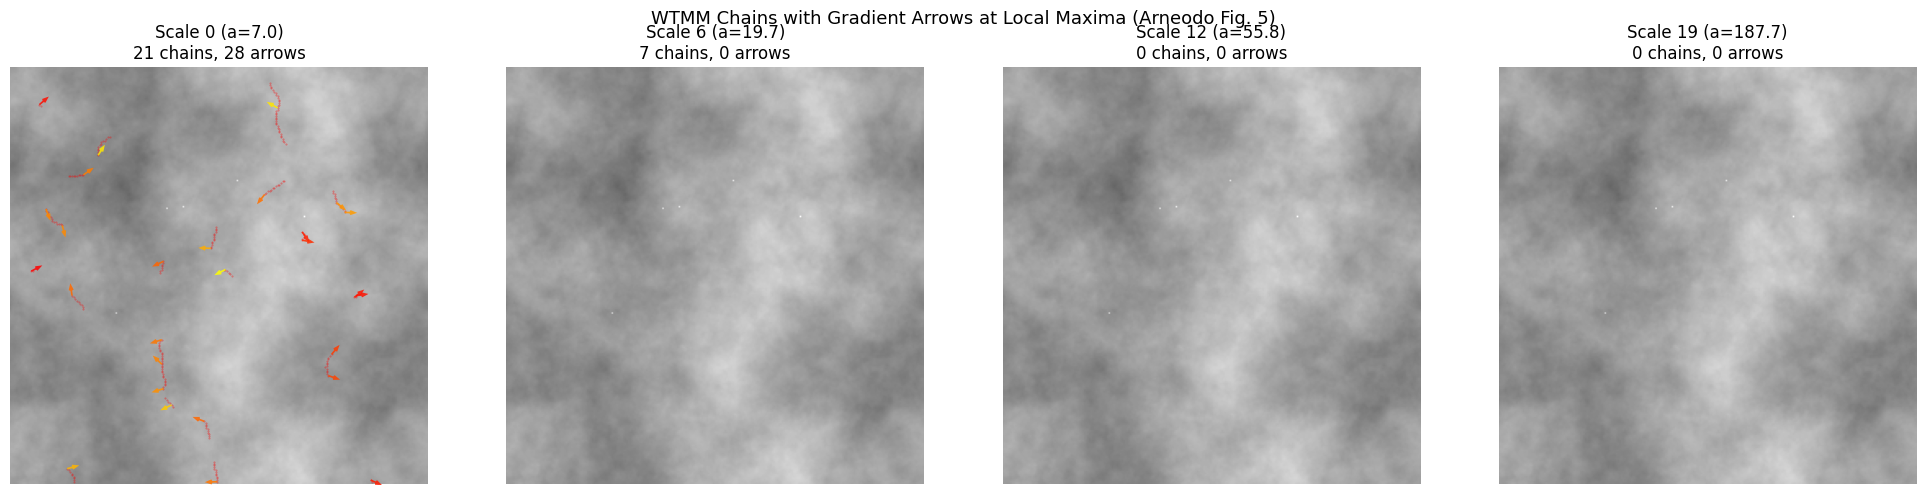

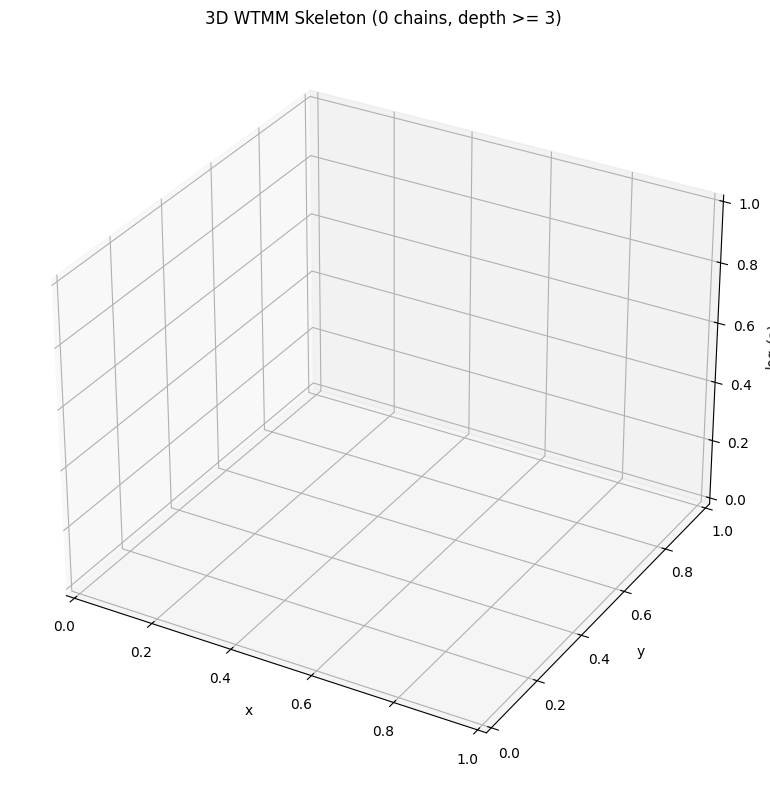

Plotted 0 chains with depth >= 3


In [ ]:
# --- Per-scale chain view with gradient arrows (Arneodo Fig. 5) ---

def find_chain_local_maxima(ei):
    """Find local maxima of modulus along each Line (connected chain).
    
    Walks each chain's ordered extrema and finds points where modulus is
    greater than both neighbors.  Endpoints are included if they exceed
    their single neighbor.  Returns one (x, y, mod, arg) per local max.
    """
    xs, ys, mods, args = [], [], [], []
    for line in ei.lines:
        exts = line.extrema
        n = len(exts)
        if n == 0:
            continue
        # Filter to active (not deleted) extrema, preserving order
        active_exts = [e for e in exts if ei.ext_ord[e.ext_idx] > 0]
        na = len(active_exts)
        if na == 0:
            continue
        if na == 1:
            # Single extremum chain — it is trivially a local max
            e = active_exts[0]
            xs.append(e.x); ys.append(e.y)
            mods.append(e.mod); args.append(e.arg)
            continue
        # Walk the chain and find local maxima
        for i, e in enumerate(active_exts):
            prev_mod = active_exts[i - 1].mod if i > 0 else -1.0
            next_mod = active_exts[i + 1].mod if i < na - 1 else -1.0
            if e.mod >= prev_mod and e.mod >= next_mod:
                xs.append(e.x); ys.append(e.y)
                mods.append(e.mod); args.append(e.arg)
    return np.array(xs), np.array(ys), np.array(mods), np.array(args)


def plot_chains_with_arrows(ext_images, test_image, scales,
                            display_scales=None):
    """Plot chains overlaid on image with gradient arrows at chain local maxima.
    
    At each displayed scale:
    - Background: the original image
    - Chain extrema drawn as thin scatter points
    - Arrow at each local maximum of modulus along each chain
    - Arrow direction = gradient argument, length proportional to modulus
    """
    if display_scales is None:
        display_scales = np.linspace(0, len(scales)-1, 4, dtype=int)
    
    n_disp = len(display_scales)
    fig, axes = plt.subplots(1, n_disp, figsize=(5 * n_disp, 5))
    if n_disp == 1:
        axes = [axes]
    
    for col, s_idx in enumerate(display_scales):
        ax = axes[col]
        ei = ext_images[s_idx]
        
        # Background: original image
        ax.imshow(test_image, cmap='gray', alpha=0.6)
        
        # Draw all active chain extrema as thin scatter points
        active = ei.ext_ord > 0
        if np.any(active):
            ax.scatter(ei.ext_x[active], ei.ext_y[active],
                      c='red', s=0.2, alpha=0.4)
        
        # Arrows at local maxima along each chain
        x_arr, y_arr, mod_arr, arg_arr = find_chain_local_maxima(ei)
        if len(x_arr) > 0:
            u = np.cos(arg_arr)
            v = np.sin(arg_arr)
            
            ax.quiver(x_arr, y_arr, u, v, mod_arr,
                     cmap='autumn', scale=8, width=0.004,
                     headwidth=3, headlength=4, alpha=0.85,
                     scale_units='inches')
        
        n_arrows = len(x_arr)
        n_chains = len([l for l in ei.lines if len(l.extrema) > 0])
        ax.set_title(f'Scale {s_idx} (a={scales[s_idx]:.1f})\n'
                     f'{n_chains} chains, {n_arrows} arrows')
        ax.set_xlim(0, test_image.shape[1])
        ax.set_ylim(test_image.shape[0], 0)
        ax.axis('off')
    
    fig.suptitle('WTMM Chains with Gradient Arrows at Local Maxima (Arneodo Fig. 5)',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

# Display at 4 representative scales
display_scales = np.linspace(0, len(scales)-1, 4, dtype=int)
plot_chains_with_arrows(ext_images, test_image, scales,
                        display_scales=display_scales)

# --- 3D Skeleton View (Arneodo Fig. 6) ---

def plot_3d_skeleton(ext_images, scales, max_chains=500, min_depth=3):
    """Plot 3D skeleton: x, y, log2(a) with chains as vertical lines.
    
    Each vertical chain = a line rising through scale space.
    Color by modulus intensity.
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    n_scales = len(ext_images)
    log2_scales = np.log2(scales)
    
    # Trace chains from finest scale
    chains_plotted = 0
    ei0 = ext_images[0]
    
    # Sort by modulus to plot strongest chains
    active_mask = ei0.ext_ord > 0
    active_idx = np.where(active_mask)[0]
    if len(active_idx) == 0:
        print("No active chains to plot")
        return
    
    sorted_idx = active_idx[np.argsort(ei0.ext_mod[active_idx])[::-1]]
    
    for fi in sorted_idx:
        if chains_plotted >= max_chains:
            break
        
        xs, ys, zs, mods = [], [], [], []
        cs = 0
        ci = fi
        while cs < n_scales and ci != -1:
            ei_cs = ext_images[cs]
            if ei_cs.ext_ord[ci] == 0.0:
                break
            xs.append(ei_cs.ext_x[ci])
            ys.append(ei_cs.ext_y[ci])
            zs.append(log2_scales[cs])
            mods.append(ei_cs.ext_mod[ci])
            ci = ei_cs.coarser_link[ci] if ci < len(ei_cs.coarser_link) else -1
            cs += 1
        
        if len(xs) >= min_depth:
            # Color by mean modulus
            mean_mod = np.mean(mods)
            ax.plot(xs, ys, zs, '-', linewidth=0.5, alpha=0.6,
                   color=plt.cm.hot(min(mean_mod / (ei0.ext_mod[active_idx].max() + 1e-10), 1.0)))
            chains_plotted += 1
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('log₂(a)')
    ax.set_title(f'3D WTMM Skeleton ({chains_plotted} chains, depth >= {min_depth})')
    plt.tight_layout()
    plt.show()
    print(f"Plotted {chains_plotted} chains with depth >= {min_depth}")

plot_3d_skeleton(ext_images, scales, max_chains=500, min_depth=3)

## 7e. Wavelet Scale Bar (per Turiel 2008, Fig. 2)

A traditional km/mi scale bar assumes a single characteristic length, but a wavelet
at scale $a$ has at least three meaningful lengths:

1. **Central-lobe width** — the "nominal" scale
2. **Zero-crossings** — set the minimum separation of features that the transform
   can resolve (Turiel et al. 2008, *J. Phys. A* 41:015501, Fig. 2: the theoretical
   wavelet can only be approximated on a pixel grid "up to a resolution which allows
   separating positive and negative parts; the zero-crossings then correspond to
   pixel boundaries")
3. **Tail extent** — sets the spatial locality of the transform (how far each
   singularity estimate is influenced by)

`add_wavelet_scalebar(...)` below draws a miniature of the wavelet profile (vertically
squished) with zero-crossings and tail endpoints marked, converted to physical units
via `px_to_unit`.  Two modes:

- **`mode='auto'`** — bar length = the actual wavelet tail-to-tail footprint at the
  displayed scale.  Use when a plot shows a single scale.
- **`mode='fixed'`** — bar length represents a user-chosen reference length (e.g.
  100 m, 2 km).  The wavelet is still drawn at the scale whose footprint equals
  that reference length, so the shape stays meaningful.  Use when a plot mixes
  multiple scales.


In [ ]:
# --- Wavelet scale bar helper (see Turiel et al. 2008, Fig. 2) ---

import matplotlib.patches as mpatches


def gaussian_gradient_profile(x, scale):
    """Scalar 1st-derivative-of-Gaussian (g1 family, 1 vanishing moment).

    Shape: x * exp(-x²/(4·scale²))
    Odd function with one zero crossing at x=0.  This is the analyzing
    wavelet xsmurf uses directly for the 'gaussian' branch (dx, dy are
    the x/y components of this gradient).
    """
    p = x * np.exp(-(x * x) / (4.0 * scale * scale))
    m = float(np.max(np.abs(p)))
    return p / m if m > 0 else p


def mexican_hat_profile(x, scale):
    """Scalar Ricker / Mexican-hat wavelet (g2 family, 3 vanishing moments).

    Shape: (1 - x²/(4·scale²)) * exp(-x²/(4·scale²))
    Symmetric with positive central peak of 1, zero crossings at x=±2·scale,
    side-lobe minima at x=±2√2·scale with value -exp(-2)≈-0.135.

    Note: xsmurf's 'mexican' branch actually uses the *gradient* of this
    function for WTMM extrema detection (dx, dy components).  For the
    scale bar we draw the parent scalar wavelet because that's what
    people recognize as "the Mexican hat" — and Turiel 2008 Fig. 2
    similarly illustrates a symmetric scalar wavelet, not its gradient.
    """
    a2 = scale * scale
    p = (1.0 - (x * x) / (4.0 * a2)) * np.exp(-(x * x) / (4.0 * a2))
    m = float(np.max(np.abs(p)))
    return p / m if m > 0 else p


# Back-compat alias for v2 name
mexican_gradient_profile = mexican_hat_profile


_WAVELET_PROFILE_REGISTRY = {
    'gaussian': gaussian_gradient_profile,   # g1, 1 vanishing moment
    'mexican':  mexican_hat_profile,         # g2, 3 vanishing moments (scalar Ricker)
}


def _wavelet_support(profile, x, tail_threshold):
    """Return (x_lo, x_hi) where |profile| first/last exceeds threshold * max|profile|."""
    pmax = float(np.max(np.abs(profile)))
    if pmax == 0:
        return float(x[0]), float(x[-1])
    mask = np.abs(profile) >= tail_threshold * pmax
    if not np.any(mask):
        return float(x[0]), float(x[-1])
    idx = np.where(mask)[0]
    return float(x[idx[0]]), float(x[idx[-1]])


def _wavelet_zero_crossings(profile, x):
    """Return x-values of sign changes in `profile` (linear interpolation)."""
    p = np.asarray(profile)
    zcs = []
    for i in range(len(p) - 1):
        a, b = p[i], p[i + 1]
        if a == 0.0:
            zcs.append(float(x[i]))
        elif a * b < 0:
            frac = -a / (b - a)
            zcs.append(float(x[i] + frac * (x[i + 1] - x[i])))
    return np.array(zcs)


def _infer_image_pixel_width(ax):
    """Return the pixel width of the first image drawn on `ax`, or None."""
    imgs = ax.get_images()
    if imgs:
        try:
            arr = imgs[0].get_array()
            return int(arr.shape[1])  # columns = pixel width
        except Exception:
            return None
    return None


def add_wavelet_scalebar(
    ax,
    *,
    mode='auto',
    scale=None,
    ref_length=None,
    px_to_unit=1.0,
    unit_str='px',
    wavelet='gaussian',
    profile_fn=None,
    tail_threshold=0.01,
    loc='lower right',
    pad_frac=0.02,
    width_frac=None,                  # None = auto-size from wavelet footprint
    min_width_frac=0.0,               # no lower clamp by default
    max_width_frac=None,              # no upper clamp → bar can overflow axes
    height_frac=0.12,
    face_alpha=0.88,
    box_color='white',
    wavelet_color='black',
    mark_color='crimson',
    fontsize=8,
    image_pixel_width=None,           # override auto-detection
):
    """Draw a wavelet-shaped scale bar on `ax`.

    The bar draws a miniature of the scalar wavelet at the displayed scale,
    with zero-crossings and tail cutoffs marked.  Its width is auto-sized
    to the wavelet's pixel footprint relative to the image's pixel width,
    so small-scale wavelets produce narrow bars and large-scale wavelets
    produce wide bars — just like a traditional scale bar at different
    zoom levels.  (Turiel et al. 2008, Fig. 2 — "zero-crossings then
    correspond to pixel boundaries ... the number of zero-crossings
    determines the minimum attainable resolution".)

    Parameters
    ----------
    ax : matplotlib Axes
    mode : {'auto', 'fixed'}
        'auto':  bar length = actual wavelet footprint at `scale`,
                 label shows the physical length.
        'fixed': bar length represents `ref_length` in `unit_str`; the
                 wavelet is drawn at the scale whose footprint equals
                 `ref_length` so its shape still matches what's being shown.
    scale : float
        Wavelet scale in pixels.  Required for mode='auto'.  Ignored in
        mode='fixed' (computed from ref_length).
    ref_length : float
        Reference length for mode='fixed' (in the same physical units that
        px_to_unit implies).  Required for mode='fixed'.
    px_to_unit : float
        Physical length of one pixel (e.g. 0.2 µm/px for EBSD).
    unit_str : str
        Unit string in the label (e.g. 'µm', 'km', 'px').
    wavelet : {'gaussian', 'mexican'}
        Which analytic profile to draw.  'gaussian' = 1st-derivative
        Gaussian (1 zero crossing).  'mexican' = scalar Ricker / Mexican
        hat (2 zero crossings, positive central peak).
    profile_fn : callable, optional
        Custom profile (x_array, scale) -> 1D ndarray.  Overrides `wavelet`.
    tail_threshold : float
        Fraction of max|profile| defining the tail cutoff (default 1%).
    loc : str
        One of {'lower right', 'lower left', 'upper right', 'upper left'}.
    pad_frac : float
        Padding from the axes edge (axes-fraction units).
    width_frac : float or None
        Bar width as a fraction of the axis.  If None (default), the
        width is auto-computed from the wavelet footprint ratio to the
        image pixel width.  Pass a number (e.g. 0.3) to use a fixed width.
    min_width_frac : float or None, default 0.0
        Optional lower clamp on the auto-computed width.  Default 0
        so the bar width truly reflects the wavelet footprint at
        small scales.
    max_width_frac : float or None, default None
        Optional upper clamp on the auto-computed width.  Default
        None so large-scale wavelets can render a bar wider than
        the image (extending past the axes edges), honestly
        showing that the wavelet exceeds the field of view.
    height_frac : float
        Bar height as a fraction of axis height.
    image_pixel_width : int, optional
        Image width in pixels — used to convert the wavelet's pixel
        footprint into an axes fraction.  Auto-detected from
        `ax.get_images()` if not provided.

    Examples
    --------
    >>> add_wavelet_scalebar(ax, mode='auto', scale=20.0,
    ...                      px_to_unit=0.2, unit_str='µm', wavelet='mexican')
    """
    if profile_fn is None:
        if wavelet not in _WAVELET_PROFILE_REGISTRY:
            raise ValueError(
                f"wavelet must be one of {list(_WAVELET_PROFILE_REGISTRY)} "
                f"or pass profile_fn=... (got {wavelet!r})"
            )
        profile_fn = _WAVELET_PROFILE_REGISTRY[wavelet]

    # --- Resolve effective scale + label value according to mode ---
    if mode == 'auto':
        if scale is None:
            raise ValueError("mode='auto' requires `scale` (wavelet scale in px).")
        eff_scale = float(scale)
        x_samples = np.linspace(-12.0 * eff_scale, 12.0 * eff_scale, 4001)
        prof = profile_fn(x_samples, eff_scale)
        x_lo, x_hi = _wavelet_support(prof, x_samples, tail_threshold)
        footprint_px = x_hi - x_lo
        label_val = footprint_px * float(px_to_unit)
    elif mode == 'fixed':
        if ref_length is None:
            raise ValueError("mode='fixed' requires `ref_length`.")
        if px_to_unit <= 0:
            raise ValueError("px_to_unit must be positive.")
        desired_footprint_px = float(ref_length) / float(px_to_unit)
        x_probe = np.linspace(-20.0, 20.0, 4001)
        prof_probe = profile_fn(x_probe, 1.0)
        x_lo_p, x_hi_p = _wavelet_support(prof_probe, x_probe, tail_threshold)
        footprint_at_s1 = x_hi_p - x_lo_p
        if footprint_at_s1 <= 0:
            raise ValueError("Could not determine wavelet footprint at scale=1.")
        eff_scale = desired_footprint_px / footprint_at_s1
        x_samples = np.linspace(-12.0 * eff_scale, 12.0 * eff_scale, 4001)
        prof = profile_fn(x_samples, eff_scale)
        x_lo, x_hi = _wavelet_support(prof, x_samples, tail_threshold)
        footprint_px = x_hi - x_lo
        label_val = float(ref_length)
    else:
        raise ValueError(f"mode must be 'auto' or 'fixed' (got {mode!r}).")

    zcs = _wavelet_zero_crossings(prof, x_samples)

    # --- Resolve bar width ---
    if width_frac is None:
        # Auto-size: compute width from footprint vs image pixel width
        img_nx = image_pixel_width
        if img_nx is None:
            img_nx = _infer_image_pixel_width(ax)
        if img_nx is None or img_nx <= 0:
            # Fallback: use axes-data width (assumes axis units == pixel count)
            xlo_ax, xhi_ax = ax.get_xlim()
            img_nx = max(1.0, abs(xhi_ax - xlo_ax))
        auto_w = footprint_px / float(img_nx)
        eff_width_frac = auto_w
        if min_width_frac is not None:
            eff_width_frac = max(float(min_width_frac), eff_width_frac)
        if max_width_frac is not None:
            eff_width_frac = min(float(max_width_frac), eff_width_frac)
    else:
        eff_width_frac = float(width_frac)

    # --- Box position in axes coordinates ---
    loc_table = {
        'lower right': (1.0 - pad_frac - eff_width_frac, pad_frac),
        'lower left':  (pad_frac,                        pad_frac),
        'upper right': (1.0 - pad_frac - eff_width_frac, 1.0 - pad_frac - height_frac),
        'upper left':  (pad_frac,                        1.0 - pad_frac - height_frac),
    }
    if loc not in loc_table:
        raise ValueError(f"loc must be one of {list(loc_table)}")
    box_x0, box_y0 = loc_table[loc]
    box_w = eff_width_frac
    box_h = height_frac

    # Background
    bg = mpatches.FancyBboxPatch(
        (box_x0, box_y0), box_w, box_h,
        boxstyle='round,pad=0.005,rounding_size=0.012',
        transform=ax.transAxes,
        facecolor=box_color, edgecolor=wavelet_color,
        alpha=face_alpha, linewidth=0.8, zorder=10,
        clip_on=False,
    )
    ax.add_patch(bg)

    # Inner drawing region for the wavelet
    h_margin = 0.02 * box_w
    bar_x0 = box_x0 + h_margin
    bar_x1 = box_x0 + box_w - h_margin
    bar_span = bar_x1 - bar_x0

    # Vertical layout: profile curve covers most of the box, label sits underneath
    band_amp_frac = 0.28
    band_cy = box_y0 + 0.62 * box_h
    label_cy = box_y0 + 0.16 * box_h

    def x_to_ax(xv):
        return bar_x0 + (xv - x_lo) / footprint_px * bar_span

    def amp_to_ax(pv):
        return band_cy + pv * band_amp_frac * box_h

    # Reference zero line
    ax.plot([bar_x0, bar_x1], [band_cy, band_cy],
            color=wavelet_color, lw=0.5, alpha=0.35,
            transform=ax.transAxes, zorder=10.5, clip_on=False)

    # Wavelet curve (cropped to [x_lo, x_hi])
    crop = (x_samples >= x_lo) & (x_samples <= x_hi)
    ax.plot(x_to_ax(x_samples[crop]), amp_to_ax(prof[crop]),
            color=wavelet_color, lw=1.3,
            transform=ax.transAxes, zorder=11, clip_on=False)

    # Zero-crossing ticks (red)
    for zc in zcs:
        if zc < x_lo or zc > x_hi:
            continue
        zc_ax = x_to_ax(zc)
        ax.plot([zc_ax, zc_ax],
                [band_cy - 0.55 * band_amp_frac * box_h,
                 band_cy + 0.55 * band_amp_frac * box_h],
                color=mark_color, lw=1.0,
                transform=ax.transAxes, zorder=12, clip_on=False)

    # Tail-end ticks (black, taller)
    for endp in (bar_x0, bar_x1):
        ax.plot([endp, endp],
                [band_cy - 0.8 * band_amp_frac * box_h,
                 band_cy + 0.8 * band_amp_frac * box_h],
                color=wavelet_color, lw=1.4,
                transform=ax.transAxes, zorder=12, clip_on=False)

    # Label text
    if label_val >= 100:
        val_str = f"{label_val:.0f}"
    elif label_val >= 10:
        val_str = f"{label_val:.1f}"
    elif label_val >= 1:
        val_str = f"{label_val:.2f}"
    else:
        val_str = f"{label_val:.3g}"

    if mode == 'auto':
        label_text = f"{val_str} {unit_str}  (a={eff_scale:.1f} px)"
    else:
        label_text = f"{val_str} {unit_str}  (ref)"

    ax.text(box_x0 + 0.5 * box_w, label_cy, label_text,
            ha='center', va='center',
            fontsize=fontsize, color=wavelet_color,
            transform=ax.transAxes, zorder=13, clip_on=False)


print("add_wavelet_scalebar: 'mexican' now draws the scalar Ricker; width auto-sizes with scale.")


In [ ]:
# --- Demo: add_wavelet_scalebar in auto + fixed modes on a single scale panel ---
#
# NOTE: DEMO_PX_TO_KM below is a PLACEHOLDER.  Replace with the real pixel size
# from your data metadata (e.g. for the InSAR velocity map, read it from the h5
# attribute or the processing params).

DEMO_PX_TO_KM = 0.02  # 1 px = 20 m = 0.02 km   <-- CHANGE ME per dataset

demo_scale_idx = len(scales) // 2
demo_scale = float(scales[demo_scale_idx])

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, mode_label in zip(axes, ['auto', 'fixed']):
    ax.imshow(test_image, cmap='gray', alpha=0.65)
    ei = ext_images[demo_scale_idx]
    active = ei.ext_ord > 0
    if np.any(active):
        ax.scatter(ei.ext_x[active], ei.ext_y[active],
                   c='red', s=0.3, alpha=0.5)
    ax.set_xlim(0, test_image.shape[1])
    ax.set_ylim(test_image.shape[0], 0)
    ax.axis('off')
    ax.set_title(f"Scale {demo_scale_idx}  (a={demo_scale:.2f} px)  —  {mode_label} scalebar")

# Auto: bar length = actual wavelet footprint at demo_scale, converted to km
add_wavelet_scalebar(
    axes[0],
    mode='auto',
    scale=demo_scale,
    px_to_unit=DEMO_PX_TO_KM, unit_str='km',
    loc='lower right',
)

# Fixed: bar length = 2 km reference (wavelet drawn at the scale whose footprint = 2 km)
add_wavelet_scalebar(
    axes[1],
    mode='fixed',
    ref_length=2.0,
    px_to_unit=DEMO_PX_TO_KM, unit_str='km',
    loc='lower right',
)

plt.tight_layout()
plt.show()


## 8. Partition Function and D(h) Singularity Spectrum

The partition function:
$$Z(q, a) = \sum_{\text{maxima chains}} |W[f](x_i, a)|^q$$

Scaling: $Z(q, a) \sim a^{\tau(q)}$

Legendre transform: $D(h) = \min_q [qh - \tau(q) + 2]$ (2 for 2D)

In [ ]:
def pf_compute_one_scale(absT_sorted, tSize, imin, q):
    """Compute partition function arrays for one scale and one q value.
    
    Matches LastWave's PFComputeOneScaleFLOAT exactly.
    
    Returns (sTq, sTqLogT, logSTq, sTqLogT_sTq, log2STq, sTqLogT_sTq2,
             logSTqSTqLogT_sTq).
    """
    if q >= 0:
        tm = absT_sorted[imin]
    else:
        tm = absT_sorted[tSize - 1]
    
    sTq_val = 0.0
    sTqLogT_val = 0.0
    
    if q >= 0:
        for i in range(imin, tSize):
            tq = absT_sorted[i] ** q
            logt = np.log(absT_sorted[i] / tm)
            sTq_val += tq
            sTqLogT_val += tq * logt
    else:
        for i in range(tSize - 1, imin - 1, -1):
            tq = absT_sorted[i] ** q
            logt = np.log(absT_sorted[i] / tm)
            sTq_val += tq
            sTqLogT_val += tq * logt
    
    # Correct for tm normalization
    sTqLogT_val = sTqLogT_val + np.log(tm) * sTq_val
    
    logSTq_val = 0.0
    sTqLogT_sTq_val = 0.0
    log2STq_val = 0.0
    sTqLogT_sTq2_val = 0.0
    logSTqSTqLogT_sTq_val = 0.0
    
    if sTq_val != 0:
        N_nonzero = tSize - imin
        logSTq_val = np.log(sTq_val / N_nonzero)
        sTqLogT_sTq_val = sTqLogT_val / sTq_val
        log2STq_val = logSTq_val * logSTq_val
        sTqLogT_sTq2_val = sTqLogT_sTq_val * sTqLogT_sTq_val
        logSTqSTqLogT_sTq_val = logSTq_val * sTqLogT_sTq_val
    
    return (sTq_val, sTqLogT_val, logSTq_val, sTqLogT_sTq_val,
            log2STq_val, sTqLogT_sTq2_val, logSTqSTqLogT_sTq_val)


def compute_partition_function_2d(ext_images, scales, q_list):
    """Compute partition function using chainmax'd ordinates.
    
    Matches LastWave PFComputeOneScaleFLOAT. Uses ext_ord arrays
    (already processed by ChainDelete + ChainMax).
    
    Returns dict with all 7 per-scale arrays plus metadata.
    """
    n_scales = len(ext_images)
    q_array = np.sort(np.array(q_list, dtype=np.float64))
    n_q = len(q_array)
    
    # All 7 arrays per q value
    sTq = np.zeros((n_q, n_scales))
    sTqLogT = np.zeros((n_q, n_scales))
    logSTq = np.zeros((n_q, n_scales))
    sTqLogT_sTq = np.zeros((n_q, n_scales))
    log2STq = np.zeros((n_q, n_scales))
    sTqLogT_sTq2 = np.zeros((n_q, n_scales))
    logSTqSTqLogT_sTq = np.zeros((n_q, n_scales))
    
    n_ext = np.zeros(n_scales, dtype=np.int64)
    
    for s_idx in range(n_scales):
        ei = ext_images[s_idx]
        # Use chainmax'd ordinates, exclude deleted (ord == 0)
        active_ord = ei.ext_ord[ei.ext_ord > 0]
        tSize = len(active_ord)
        n_ext[s_idx] = tSize
        
        if tSize == 0:
            continue
        
        absT = np.abs(active_ord).copy()
        absT.sort()
        
        imin = 0
        while imin < tSize and absT[imin] == 0:
            imin += 1
        
        if imin >= tSize:
            continue
        
        for nq in range(n_q):
            result = pf_compute_one_scale(absT, tSize, imin, q_array[nq])
            sTq[nq, s_idx] = result[0]
            sTqLogT[nq, s_idx] = result[1]
            logSTq[nq, s_idx] = result[2]
            sTqLogT_sTq[nq, s_idx] = result[3]
            log2STq[nq, s_idx] = result[4]
            sTqLogT_sTq2[nq, s_idx] = result[5]
            logSTqSTqLogT_sTq[nq, s_idx] = result[6]
    
    log2_a = np.log2(scales)
    
    return {
        'sTq': sTq,
        'sTqLogT': sTqLogT,
        'logSTq': logSTq,
        'sTqLogT_sTq': sTqLogT_sTq,
        'log2STq': log2STq,
        'sTqLogT_sTq2': sTqLogT_sTq2,
        'logSTqSTqLogT_sTq': logSTqSTqLogT_sTq,
        'q_list': q_array,
        'scales': scales.copy(),
        'log2_a': log2_a,
        'n_ext': n_ext,
    }


def compute_spectra_from_pf(pf_result, fit_range=None):
    """Compute tau(q), h(q), D(q) from partition function via linear regression.

    Matches LastWave singSpectrum (wtmm1d.pkg:31-61):
      tau(q) = slope of T(q,a) vs log2(a),  where T(q,a) = log(sTq) / ln(2)
      h(q)   = slope of H(q,a) vs log2(a),  where H(q,a) = (sTqLogT/sTq) / ln(2)
      D(q)   = slope of D(q,a) vs log2(a),  where D(q,a) = [q*sTqLogT/sTq - log(sTq)] / ln(2)

    References:
      pf_lib.c:618-638  — PFAccessTQFLOAT:  T = log(sTq)
      pf_lib.c:687-720  — PFAccessHQFLOAT:  H = sTqLogT / sTq
      pf_lib.c:756-789  — PFAccessDQFLOAT:  D = q*sTqLogT/sTq - log(sTq)
    """
    log2_a = pf_result['log2_a']
    sTq = pf_result['sTq']
    sTqLogT = pf_result['sTqLogT']
    q_array = pf_result['q_list']
    n_q = len(q_array)
    n_scales = len(log2_a)

    if fit_range is None:
        fit_range = (2, n_scales - 2)
    i0, i1 = fit_range
    la = log2_a[i0:i1]  # x-axis for regression

    tau = np.full(n_q, np.nan)
    h = np.full(n_q, np.nan)
    D = np.full(n_q, np.nan)
    tau_err = np.full(n_q, np.nan)

    LN2 = np.log(2)

    for qi in range(n_q):
        q = q_array[qi]
        s = sTq[qi, i0:i1]
        valid = (s > 0) & np.isfinite(s)
        if np.sum(valid) < 3:
            continue

        # T(q,a) = log(sTq) / ln(2) — slope vs log2(a) gives tau(q)
        Tqa = np.log(s[valid]) / LN2
        coeffs_t = np.polyfit(la[valid], Tqa, 1)
        tau[qi] = coeffs_t[0]
        res = Tqa - np.polyval(coeffs_t, la[valid])
        tau_err[qi] = np.std(res) / np.sqrt(len(res))

        # H(q,a) = (sTqLogT/sTq) / ln(2) — slope vs log2(a) gives h(q)
        slt = sTqLogT[qi, i0:i1]
        Hqa = (slt[valid] / s[valid]) / LN2
        if np.all(np.isfinite(Hqa)):
            coeffs_h = np.polyfit(la[valid], Hqa, 1)
            h[qi] = coeffs_h[0]

        # D(q,a) = [q*sTqLogT/sTq - log(sTq)] / ln(2) — slope vs log2(a) gives D(q)
        Dqa = (q * slt[valid] / s[valid] - np.log(s[valid])) / LN2
        if np.all(np.isfinite(Dqa)):
            coeffs_d = np.polyfit(la[valid], Dqa, 1)
            D[qi] = coeffs_d[0]

    return tau, h, D, tau_err


# Compute partition function with chainmax'd ordinates
q_values = np.linspace(-3, 3, 25)

print("Computing partition function Z(q, a) with chainmax'd ordinates...")
pf_result = compute_partition_function_2d(ext_images, scales, q_values)

# Compute tau(q), h(q), D(q) via slope-based method (matching LastWave singSpectrum)
fit_start = 2
fit_end = len(scales) - 2
tau, h_q, D_q, tau_err = compute_spectra_from_pf(pf_result, fit_range=(fit_start, fit_end))

q_arr = pf_result['q_list']
print(f"tau(0) = {tau[np.argmin(np.abs(q_arr))]:.3f} (expected: ~-2 for 2D)")
print(f"tau(1) = {tau[np.argmin(np.abs(q_arr - 1))]:.3f}")
print(f"tau(2) = {tau[np.argmin(np.abs(q_arr - 2))]:.3f}")
print(f"Active extrema per scale: min={pf_result['n_ext'].min()}, "
      f"max={pf_result['n_ext'].max()}")

# Show h(q) and D(q) from slope method
valid_hd = np.isfinite(h_q) & np.isfinite(D_q)
if np.any(valid_hd):
    print(f"\nSlope-based D(h) spectrum:")
    print(f"  h range: [{np.nanmin(h_q[valid_hd]):.3f}, {np.nanmax(h_q[valid_hd]):.3f}]")
    print(f"  D range: [{np.nanmin(D_q[valid_hd]):.3f}, {np.nanmax(D_q[valid_hd]):.3f}]")
    q0_idx = np.argmin(np.abs(q_arr))
    print(f"  h(q=0) = {h_q[q0_idx]:.3f}, D(q=0) = {D_q[q0_idx]:.3f}")

Computing partition function Z(q, a) with chainmax'd ordinates...
tau(0) = nan (expected: ~-2 for 2D)
tau(1) = nan
tau(2) = nan
Active extrema per scale: min=0, max=239


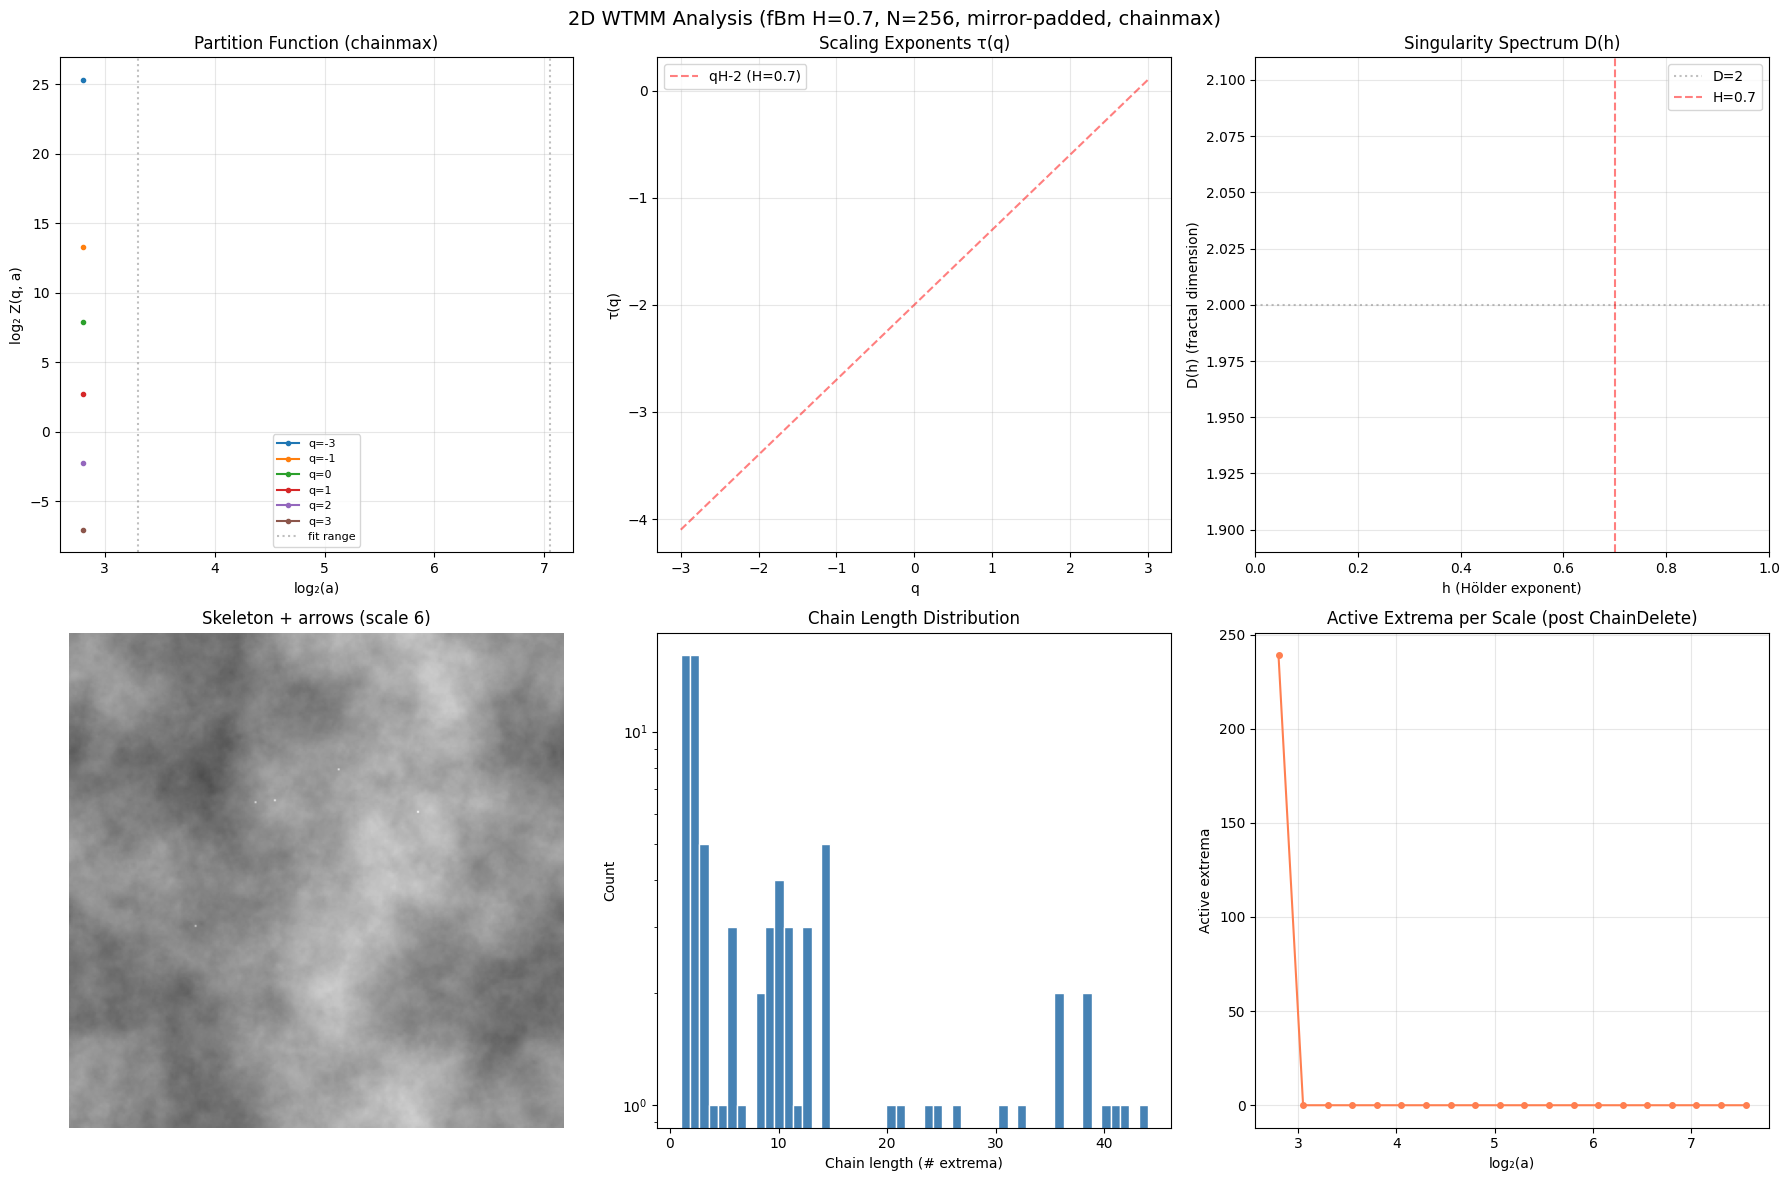

In [ ]:
# Comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Partition function Z(q, a)
ax = axes[0, 0]
q_display = [-3, -1, 0, 1, 2, 3]
log2_a = pf_result['log2_a']
for q in q_display:
    q_idx = np.argmin(np.abs(q_arr - q))
    z_vals = pf_result['sTq'][q_idx]
    valid = np.isfinite(z_vals) & (z_vals > 0)
    if np.any(valid):
        ax.plot(log2_a[valid], np.log2(z_vals[valid]), 'o-', label=f'q={q}', markersize=3)
# Show fit range
ax.axvline(log2_a[fit_start], color='gray', ls=':', alpha=0.5)
ax.axvline(log2_a[fit_end - 1], color='gray', ls=':', alpha=0.5, label='fit range')
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂ Z(q, a)')
ax.set_title('Partition Function (chainmax)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. tau(q) spectrum
ax = axes[0, 1]
valid_tau = np.isfinite(tau)
ax.errorbar(q_arr[valid_tau], tau[valid_tau], yerr=tau_err[valid_tau],
            fmt='b.-', capsize=2)
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('Scaling Exponents τ(q)')
ax.grid(True, alpha=0.3)
ax.plot(q_arr, q_arr * H_true - 2, 'r--', alpha=0.5, label=f'qH-2 (H={H_true})')
ax.legend()

# 3. D(h) singularity spectrum — sorted by h (matching singSpectrum 'sort result')
ax = axes[0, 2]
valid_dh = np.isfinite(h_q) & np.isfinite(D_q)
if np.any(valid_dh):
    h_plot = h_q[valid_dh]
    D_plot = D_q[valid_dh]
    # Sort by h as in LastWave singSpectrum
    sort_idx = np.argsort(h_plot)
    h_plot = h_plot[sort_idx]
    D_plot = D_plot[sort_idx]
    ax.plot(h_plot, D_plot, 'g.-', markersize=8, label='slope-based D(h)')
ax.set_xlabel('h (Hölder exponent)')
ax.set_ylabel('D(h) (fractal dimension)')
ax.set_title('Singularity Spectrum D(h)')
ax.axhline(y=2, color='gray', linestyle=':', alpha=0.5, label='D=2')
ax.axvline(x=H_true, color='r', linestyle='--', alpha=0.5, label=f'H={H_true}')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Skeleton overlay with arrows on original image
ax = axes[1, 0]
ax.imshow(test_image, cmap='gray', alpha=0.7)
# Overlay extrema from selected scales with arrows
arrow_scale_idx = len(scales) // 3  # pick a mid scale
ei_arrow = ext_images[arrow_scale_idx]
active = ei_arrow.ext_ord > 0
if np.any(active):
    active_idx = np.where(active)[0]
    # Subsample for clarity
    n_show = min(200, len(active_idx))
    show_idx = active_idx[np.argsort(ei_arrow.ext_mod[active_idx])[-n_show:]]
    ax.scatter(ei_arrow.ext_x[show_idx], ei_arrow.ext_y[show_idx],
              c=ei_arrow.ext_mod[show_idx], cmap='hot', s=2, alpha=0.7)
    # Arrows
    u = np.cos(ei_arrow.ext_arg[show_idx])
    v = np.sin(ei_arrow.ext_arg[show_idx])
    sf = 3.0 * ei_arrow.ext_mod[show_idx] / (ei_arrow.ext_mod[show_idx].max() + 1e-10)
    ax.quiver(ei_arrow.ext_x[show_idx], ei_arrow.ext_y[show_idx],
             u * sf, v * sf, ei_arrow.ext_mod[show_idx],
             cmap='autumn', scale=25, width=0.003, alpha=0.7)
ax.set_title(f'Skeleton + arrows (scale {arrow_scale_idx})')
ax.axis('off')

# 5. Chain length distribution
ax = axes[1, 1]
all_chain_lengths = []
for ei in ext_images:
    for line in ei.lines:
        all_chain_lengths.append(len(line.extrema))
ax.hist(all_chain_lengths, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Chain length (# extrema)')
ax.set_ylabel('Count')
ax.set_title('Chain Length Distribution')
ax.set_yscale('log')

# 6. Active extrema per scale (after ChainDelete)
ax = axes[1, 2]
ax.plot(log2_a, pf_result['n_ext'], 'o-', color='coral', markersize=4)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('Active extrema')
ax.set_title('Active Extrema per Scale (post ChainDelete)')
ax.grid(True, alpha=0.3)

plt.suptitle(f'2D WTMM Analysis (fBm H={H_true}, N={N}, mirror-padded, chainmax)',
             fontsize=14)
plt.tight_layout()
plt.show()

## 9. Tensor WTMM (Vector Field Analysis)

Port of `GradientModulus2D_tensor2D` from `edge/misc.c`.
For a vector field **F** = (f₁, f₂), the wavelet transform produces
a 2×2 Jacobian tensor at each point. SVD decomposes it to extract:
- **SVD_TYPE_MAX**: Modulus = largest singular value
- **SVD_TYPE_MIN**: Modulus = smallest singular value
- **Longitudinal/Transverse (LT)**: Symmetric/antisymmetric decomposition

Tensor WTMM demonstration:
Creating synthetic vector field from two fBm fields...
Computing tensor SVD (vectorized)...


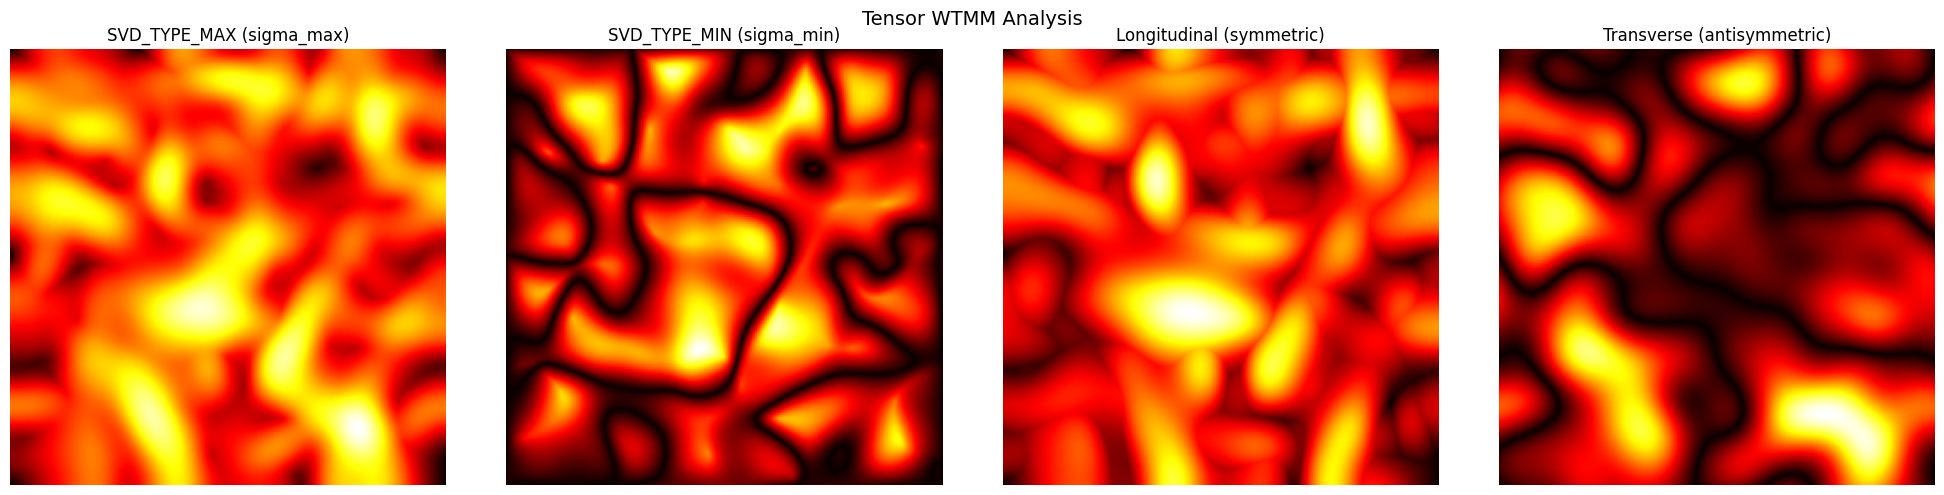

sigma_max range: [0.0015, 0.1160]
sigma_min range: [0.0000, 0.0599]
modL range:  [0.0005, 0.0988]
modT range:  [0.0000, 0.0630]


In [ ]:
# SVD type enum (from edge/misc.h)
SVD_TYPE_MAX = 0
SVD_TYPE_MIN = 1
SVD_TYPE_MAX_L = 2
SVD_TYPE_MAX_T = 3

def gradient_modulus_tensor_2d(gx1, gy1, gx2, gy2, svd_type=SVD_TYPE_MAX):
    """
    Port of xsmurf GradientModulus2D_tensor2D (edge/misc.c).
    
    Computes SVD of the 2x2 wavelet tensor at each pixel:
        T = [[gx1, gx2],
             [gy1, gy2]]
    
    Parameters:
        gx1, gy1: wavelet transform of first field component
        gx2, gy2: wavelet transform of second field component
        svd_type: which singular value to use
    
    Returns:
        modulus, argument: gradient modulus and direction
    """
    ny, nx = gx1.shape
    modulus = np.zeros((ny, nx))
    argument = np.zeros((ny, nx))
    
    for y in range(ny):
        for x in range(nx):
            # Build 2x2 tensor
            T = np.array([[gx1[y, x], gx2[y, x]],
                         [gy1[y, x], gy2[y, x]]])
            
            # SVD
            U, s, Vt = np.linalg.svd(T)
            
            if svd_type == SVD_TYPE_MAX:
                idx = 0  # largest singular value
            elif svd_type == SVD_TYPE_MIN:
                idx = 1  # smallest singular value
            else:
                idx = 0
            
            modulus[y, x] = s[idx]
            # Direction from left singular vector
            argument[y, x] = np.arctan2(U[1, idx], U[0, idx])
    
    return modulus, argument

def gradient_modulus_tensor_2d_vectorized(gx1, gy1, gx2, gy2, svd_type=SVD_TYPE_MAX):
    """
    Vectorized version using numpy batch SVD.
    Much faster than per-pixel loop.
    """
    ny, nx = gx1.shape
    
    # Stack into (ny*nx, 2, 2) tensor array
    T = np.stack([np.stack([gx1.ravel(), gx2.ravel()], axis=-1),
                  np.stack([gy1.ravel(), gy2.ravel()], axis=-1)], axis=-2)
    
    # Batch SVD
    U, s, Vt = np.linalg.svd(T)
    
    if svd_type == SVD_TYPE_MAX:
        idx = 0
    elif svd_type == SVD_TYPE_MIN:
        idx = 1
    else:
        idx = 0
    
    modulus = s[:, idx].reshape(ny, nx)
    argument = np.arctan2(U[:, 1, idx], U[:, 0, idx]).reshape(ny, nx)
    
    return modulus, argument

def gradient_modulus_tensor_2d_LT(gx1, gy1, gx2, gy2):
    """
    Port of xsmurf GradientModulus2D_tensor2D_LT (edge/misc.c).
    
    Decompose tensor into longitudinal (symmetric) and transverse (antisymmetric) parts.
    
    modL = max(|gx1|, |gy2|, 0.5*|gx2 + gy1|)  (symmetric part)
    modT = 0.5 * |gx2 - gy1|                     (antisymmetric part)
    """
    modL = np.maximum(np.maximum(np.abs(gx1), np.abs(gy2)),
                      0.5 * np.abs(gx2 + gy1))
    modT = 0.5 * np.abs(gx2 - gy1)
    
    return modL, modT

# Demo: Apply tensor analysis to a synthetic vector field
print("Tensor WTMM demonstration:")
print("Creating synthetic vector field from two fBm fields...")

# Two independent fBm fields as vector components
f1 = generate_fbm_2d(N, H=0.5, seed=42)
f2 = generate_fbm_2d(N, H=0.7, seed=99)

# Mirror-pad both fields
f1_padded, f1_crop = mirror_pad_image(f1, PAD_WIDTH)
f2_padded, f2_crop = mirror_pad_image(f2, PAD_WIDTH)

# CWT of both fields (using MLX FFT + mirror padding)
wx1, wy1 = cwt_2d(f1_padded, scales[:4], f1_crop)
wx2, wy2 = cwt_2d(f2_padded, scales[:4], f2_crop)

# Tensor analysis at one scale
print("Computing tensor SVD (vectorized)...")
mod_max, arg_max = gradient_modulus_tensor_2d_vectorized(
    wx1[2], wy1[2], wx2[2], wy2[2], SVD_TYPE_MAX)
mod_min, arg_min = gradient_modulus_tensor_2d_vectorized(
    wx1[2], wy1[2], wx2[2], wy2[2], SVD_TYPE_MIN)

# LT decomposition
modL, modT = gradient_modulus_tensor_2d_LT(wx1[2], wy1[2], wx2[2], wy2[2])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(mod_max, cmap='hot')
axes[0].set_title('SVD_TYPE_MAX (sigma_max)')
axes[1].imshow(mod_min, cmap='hot')
axes[1].set_title('SVD_TYPE_MIN (sigma_min)')
axes[2].imshow(modL, cmap='hot')
axes[2].set_title('Longitudinal (symmetric)')
axes[3].imshow(modT, cmap='hot')
axes[3].set_title('Transverse (antisymmetric)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Tensor WTMM Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f"sigma_max range: [{mod_max.min():.4f}, {mod_max.max():.4f}]")
print(f"sigma_min range: [{mod_min.min():.4f}, {mod_min.max():.4f}]")
print(f"modL range:  [{modL.min():.4f}, {modL.max():.4f}]")
print(f"modT range:  [{modT.min():.4f}, {modT.max():.4f}]")

## 10. Summary and Validation

This notebook implements the complete xsmurf 2D WTMM pipeline:

| Component | xsmurf Source | Python Port |
|-----------|--------------|-------------|
| Wavelet defs | `wt.tcl` | `gaussian_derivative_wavelet_2d_fourier` + `third_order_wavelets_2d_fourier` |
| CWT (FFT) | `cv2d_a_real_ft` | `cwt_2d` (MLX GPU) + `cwt_2d_all_derivatives` |
| Gradient mod/arg | `edge/misc.c` | `gradient_modulus_2d` / `gradient_argument_2d` |
| WTMM detection (NMS) | `edge/extrema_core.c` | `non_maxima_suppression_2d` (`useNMaxSup=1`) |
| WTMM detection (follow) | `wt2d/Extrema.c` | `follow_contour_2d` via `compute_kapa_kapap` (`useNMaxSup=0`) |
| Chain extraction | `wt2d/chain.c` `search_lines` | `search_lines` (8-connected DFS walk) |
| Single max | `wt2d/single_max.c` | `search_single_max` (spatial grid check) |
| Vertical chaining | `wt2d/chain2.c` `vert_chain` | `vert_chain` (box search + similitude) |
| Skeleton | `wt2d/vertical_chain.c` | `construct_skeleton` (proximity matching) |
| ChainDelete | LastWave `ChainDelete` | `chain_delete_2d` |
| ChainMax | LastWave `ChainMax` | `chain_max_2d` |
| Partition function | `pf_lib.c` | `pf_compute_one_scale` + `compute_spectra_from_pf` |

Pipeline per scale (from `tcl_library/eiChain.tcl`):
```
hsearch -> ssm -> vchain (with boxSize = int(log(a)*2/log(2)), similitude=0.8)
```

In [ ]:
print("="*60)
print("2D WTMM Analysis Complete")
print("="*60)
print(f"Image size: {N}x{N} (padded to {test_image_padded.shape})")
print(f"Hurst exponent: H = {H}")
print(f"Scales: {len(scales)} ({n_octaves} octaves x {n_voices} voices)")
print(f"Scale range: [{scales[0]:.2f}, {scales[-1]:.2f}]")
print(f"WTMM method: {WTMM_METHOD}")
print(f"Total extrema: {total_extrema}")
print(f"Total chains: {total_chains}")
print(f"Total single max: {total_gr}")
print(f"Cross-scale links: {n_linked}")
print(f"Chain ordering violations: {violations}")
print(f"Surfaces: {len(surfaces)} ({len(multi_scale)} multi-scale, max depth {max_depth})")
print("="*60)

2D WTMM Analysis Complete
Image size: 256x256 (padded to (320, 320))


Error: NameError: name 'H' is not defined
[31m---------------------------------------------------------------------------[39m
[31mNameError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[92][39m[32m, line 5[39m
[32m      3[39m [38;5;28mprint[39m([33m"[39m[33m=[39m[33m"[39m*[32m60[39m)
[32m      4[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mImage size: [39m[38;5;132;01m{[39;00mN[38;5;132;01m}[39;00m[33mx[39m[38;5;132;01m{[39;00mN[38;5;132;01m}[39;00m[33m (padded to [39m[38;5;132;01m{[39;00mtest_image_padded.shape[38;5;132;01m}[39;00m[33m)[39m[33m"[39m)
[32m----> [39m[32m5[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mHurst exponent: H = [39m[38;5;132;01m{[39;00m[43mH[49m[38;5;132;01m}[39;00m[33m"[39m)
[32m      6[39m [38;5;28mprint[39m([33mf[39m[33m"[39m[33mScales: [39m[38;5;132;01m{[39;00m[38;5;28mlen[39m(scales)[38;5;132;01m}[39;00m[33m ([39m[

## InSAR Velocity Map — Load + CWT

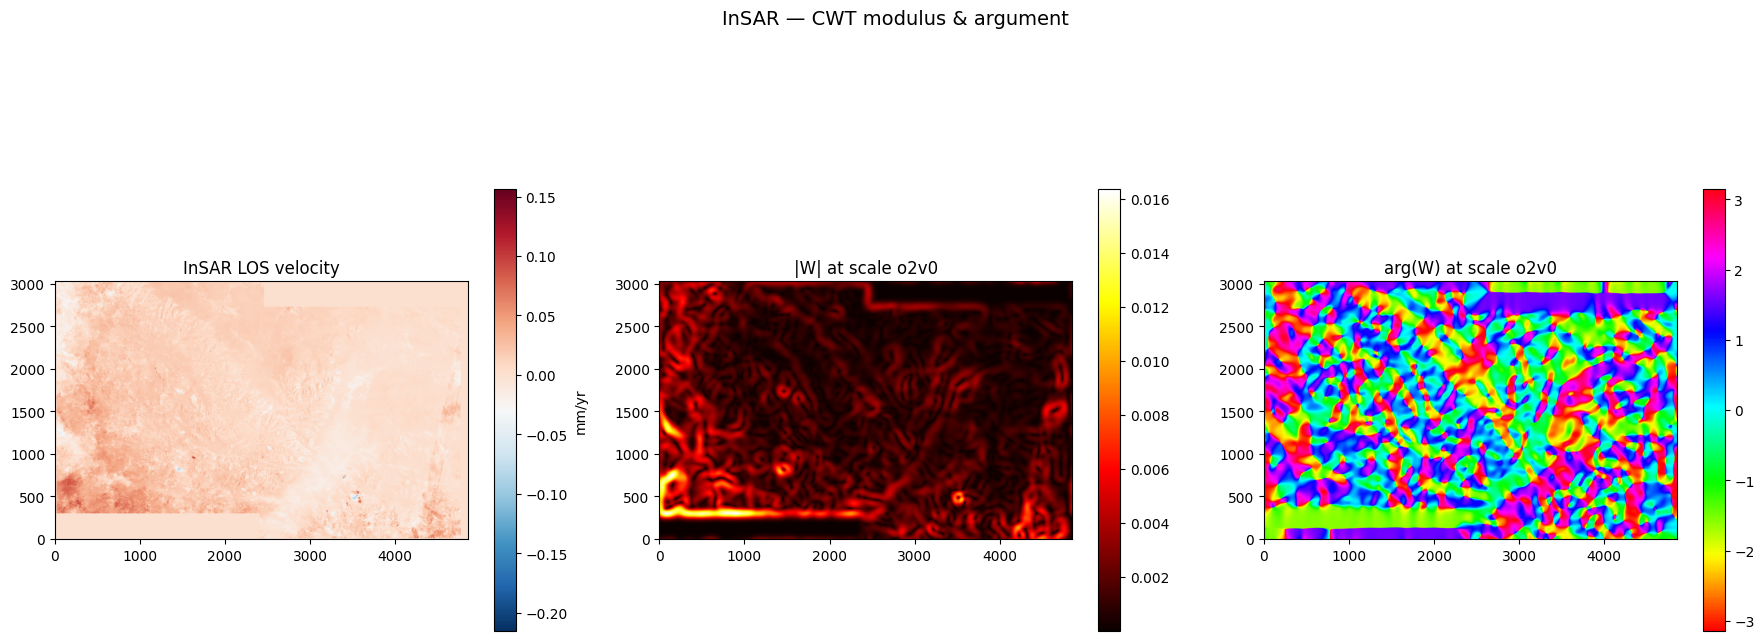

Image: (3029, 4855), CWT: (16, 3029, 4855), 16 scales


In [30]:
import h5py

h5_path = '/Volumes/AbeMBeats/new_data_asif/velocity.h5'
with h5py.File(h5_path, 'r') as f:
    vel = f['velocity'][:]

test_image = vel[0].astype(np.float64) if vel.ndim == 3 else vel.astype(np.float64)
test_image = np.nan_to_num(test_image, nan=0.0)

PAD_WIDTH = 32
test_image_padded, crop_slice = mirror_pad_image(test_image, PAD_WIDTH)

# CWT
scales, scale_labels = compute_scales(n_octaves, n_voices, a_min=1.0)
wx, wy = cwt_2d(test_image_padded, scales, crop_slice)

# Gradient modulus + argument
modulus = np.sqrt(wx**2 + wy**2)
argument = np.arctan2(wy, wx)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
im0 = axes[0].imshow(test_image, origin='lower', cmap='RdBu_r')
plt.colorbar(im0, ax=axes[0], label='mm/yr', shrink=0.6)
axes[0].set_title('InSAR LOS velocity')

mid = len(scales) // 2
im1 = axes[1].imshow(modulus[mid], origin='lower', cmap='hot')
plt.colorbar(im1, ax=axes[1], shrink=0.6)
axes[1].set_title(f'|W| at scale {scale_labels[mid]}')

im2 = axes[2].imshow(argument[mid], origin='lower', cmap='hsv')
plt.colorbar(im2, ax=axes[2], shrink=0.6)
axes[2].set_title(f'arg(W) at scale {scale_labels[mid]}')

plt.suptitle('InSAR — CWT modulus & argument', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Image: {test_image.shape}, CWT: {wx.shape}, {len(scales)} scales")